## 00. Imports

In [1]:
import numpy as np

In [2]:
#import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from tensorflow.keras.datasets import mnist
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
import concurrent.futures
import json
import os

from graph_based_codebase import extract_graph, merge_similar_edges, detect_curvatures
from graph_based_codebase import extract_long_paths, fit_bezier_curve, get_bezier_curve_points
from graph_based_codebase import identify_and_display_curves, plot_graph_with_beziers_multigraph
from graph_based_codebase import detect_almost_circles, plot_almost_circles


#import bezier
from scipy import ndimage as ndi

## 01. Download the datasets

In [3]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

## 02. Preprocess imgaes - extract edges and skeletonize

## 02.A 1st method

In [4]:
def preprocess_image(img, threshold=30):
    # Normalize and convert to uint8
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    # Apply a binary threshold to clean noise
    _, img = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)
    return img

def extract_edges(img):
    # Use Canny edge detector
    edges = cv2.Canny(img, threshold1=100, threshold2=125)
    return edges

def image_to_graph(edge_img, connectivity=8):
    """
    Convert edge pixels to a graph.
    Each white pixel becomes a node.
    Nodes are connected if they're adjacent (based on connectivity).
    """
    G = nx.Graph()
    h, w = edge_img.shape

    for y in range(h):
        for x in range(w):
            if edge_img[y, x] == 255:
                G.add_node((x, -y))  # Pixel coordinates as node ID

                # Define neighborhood offsets
                neighbors = [(-1, -1), (-1, 0), (-1, 1),
                             ( 0, -1),          ( 0, 1),
                             ( 1, -1), ( 1, 0), ( 1, 1)] if connectivity == 8 else [(-1, 0), (0, -1), (0, 1), (1, 0)]

                for dy, dx in neighbors:
                    ny, nx_ = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx_ < w and edge_img[ny, nx_] == 255:
                        G.add_edge((x, -y), (nx_, -ny))
    return G

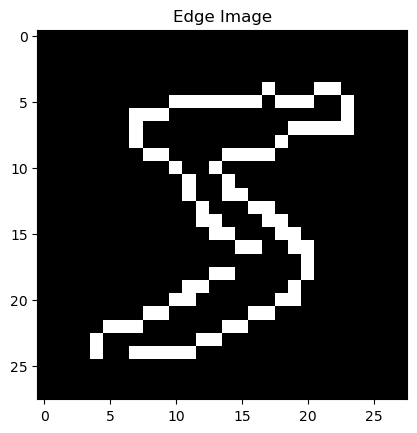

Graph has 83 nodes and 97 edges.


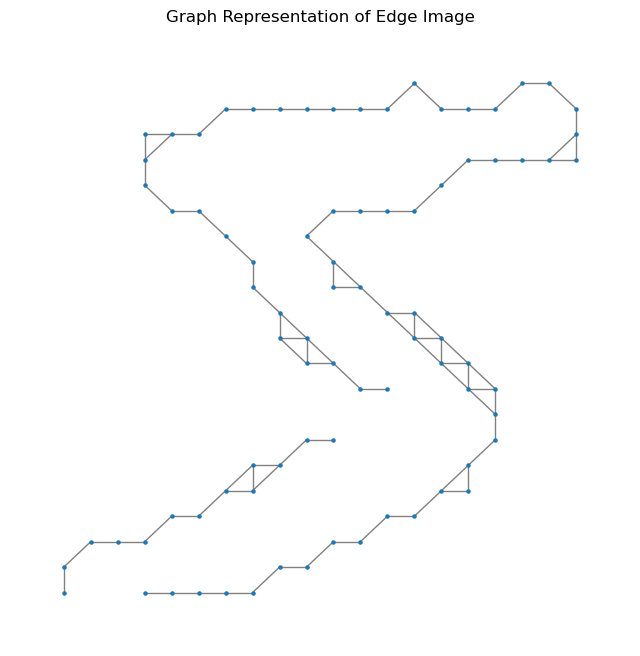

In [5]:
img = x_train[0]  # Pick the first digit

preprocessed = preprocess_image(img)
edges = extract_edges(preprocessed)
graph = image_to_graph(edges)

# Optional: show image
plt.imshow(edges, cmap='gray')
plt.title("Edge Image")
plt.show()

def plot_graph(G, ax):
    """Plot the graph on the given axis."""
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', with_labels=False)

fig, ax = plt.subplots(figsize=(8, 8))
plot_graph(graph, ax)
plt.title("Graph Representation of Edge Image")
print(f"Graph has {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges.")

## 02.B 2nd method 

In [6]:
def mnist_to_graph(img):
    # Load image

    # Preprocess
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    #img = cv2.medianBlur(img,3)
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY) # I tried with 0, 5, 20, 30

    # print unique values in img
    #print(np.unique(binary))

    # Edge detection
    edges = cv2.Canny(binary, 100, 200)

    # Skeletonization: input must be boolean
    skeleton = skeletonize(edges > 0).astype(np.uint8)

    # Graph extraction
    graph = extract_graph(skeleton)

    # Optional: show intermediate steps
    # fig, axs = plt.subplots(1, 3, figsize=(9, 3))
    # axs[0].imshow(img, cmap='gray'); axs[0].set_title("Original")
    # axs[1].imshow(edges, cmap='gray'); axs[1].set_title("Edges")
    # axs[2].imshow(skeleton, cmap='gray'); axs[2].set_title("Skeleton")
    # plt.tight_layout(); plt.show()

    return graph

Graph has 82 nodes and 82 edges.


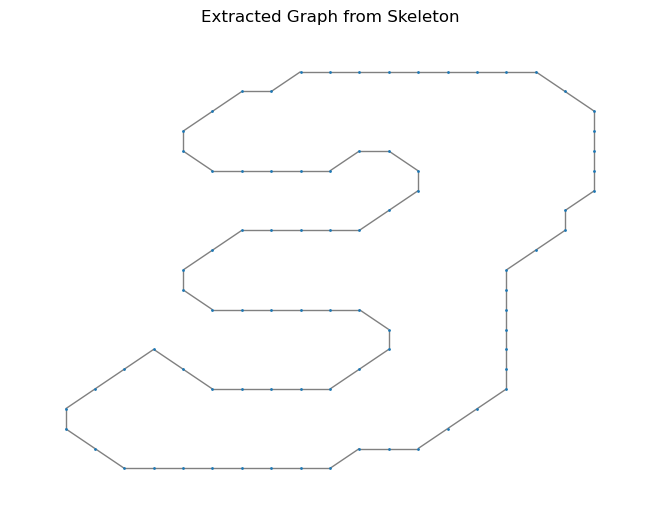

In [7]:
img = x_train[y_train == 3][0]  # Pick the first digit of class '1'
G = mnist_to_graph(img)
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# Optional: draw graph with positions
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, node_size=1, edge_color='gray')
plt.title("Extracted Graph from Skeleton")
plt.show()

### Compare results of method A and B

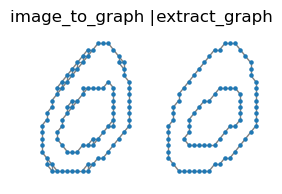

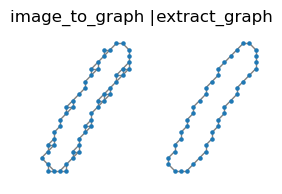

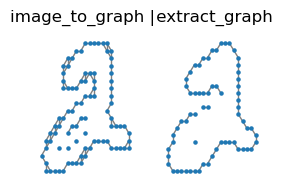

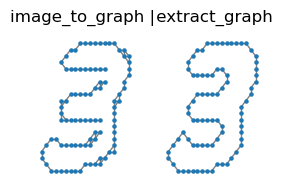

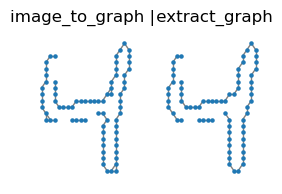

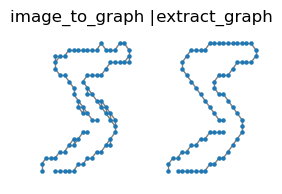

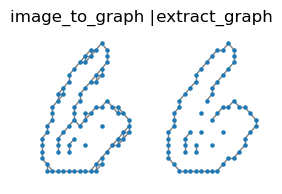

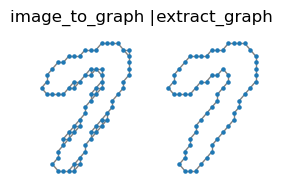

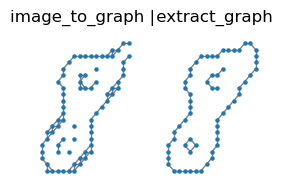

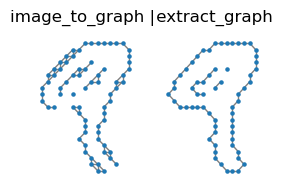

In [22]:
# compare graphs created with 2 different functions
def compare_graphs(digit):
    fig, axs = plt.subplots(1, 2, figsize=(3, 2))
    img = x_train[y_train == digit][0]  # Pick the first digit

    ## first graph
    preprocessed = preprocess_image(img)
    edges = extract_edges(preprocessed)
    graph1 = image_to_graph(edges)
    plot_graph(graph1, axs[0])
    axs[0].set_title("image_to_graph | ")

    ## second graph
    graph2 = mnist_to_graph(img)
    plot_graph(graph2, axs[1])
    axs[1].set_title(" extract_graph")
    plt.show()

for digit in range(10):
    # img = x_train[y_train == digit][0]
    # preprocessed = preprocess_image(img)
    # edges = extract_edges(preprocessed)
    compare_graphs(digit)
    

### Show 2nd method for 10 examples of each digit

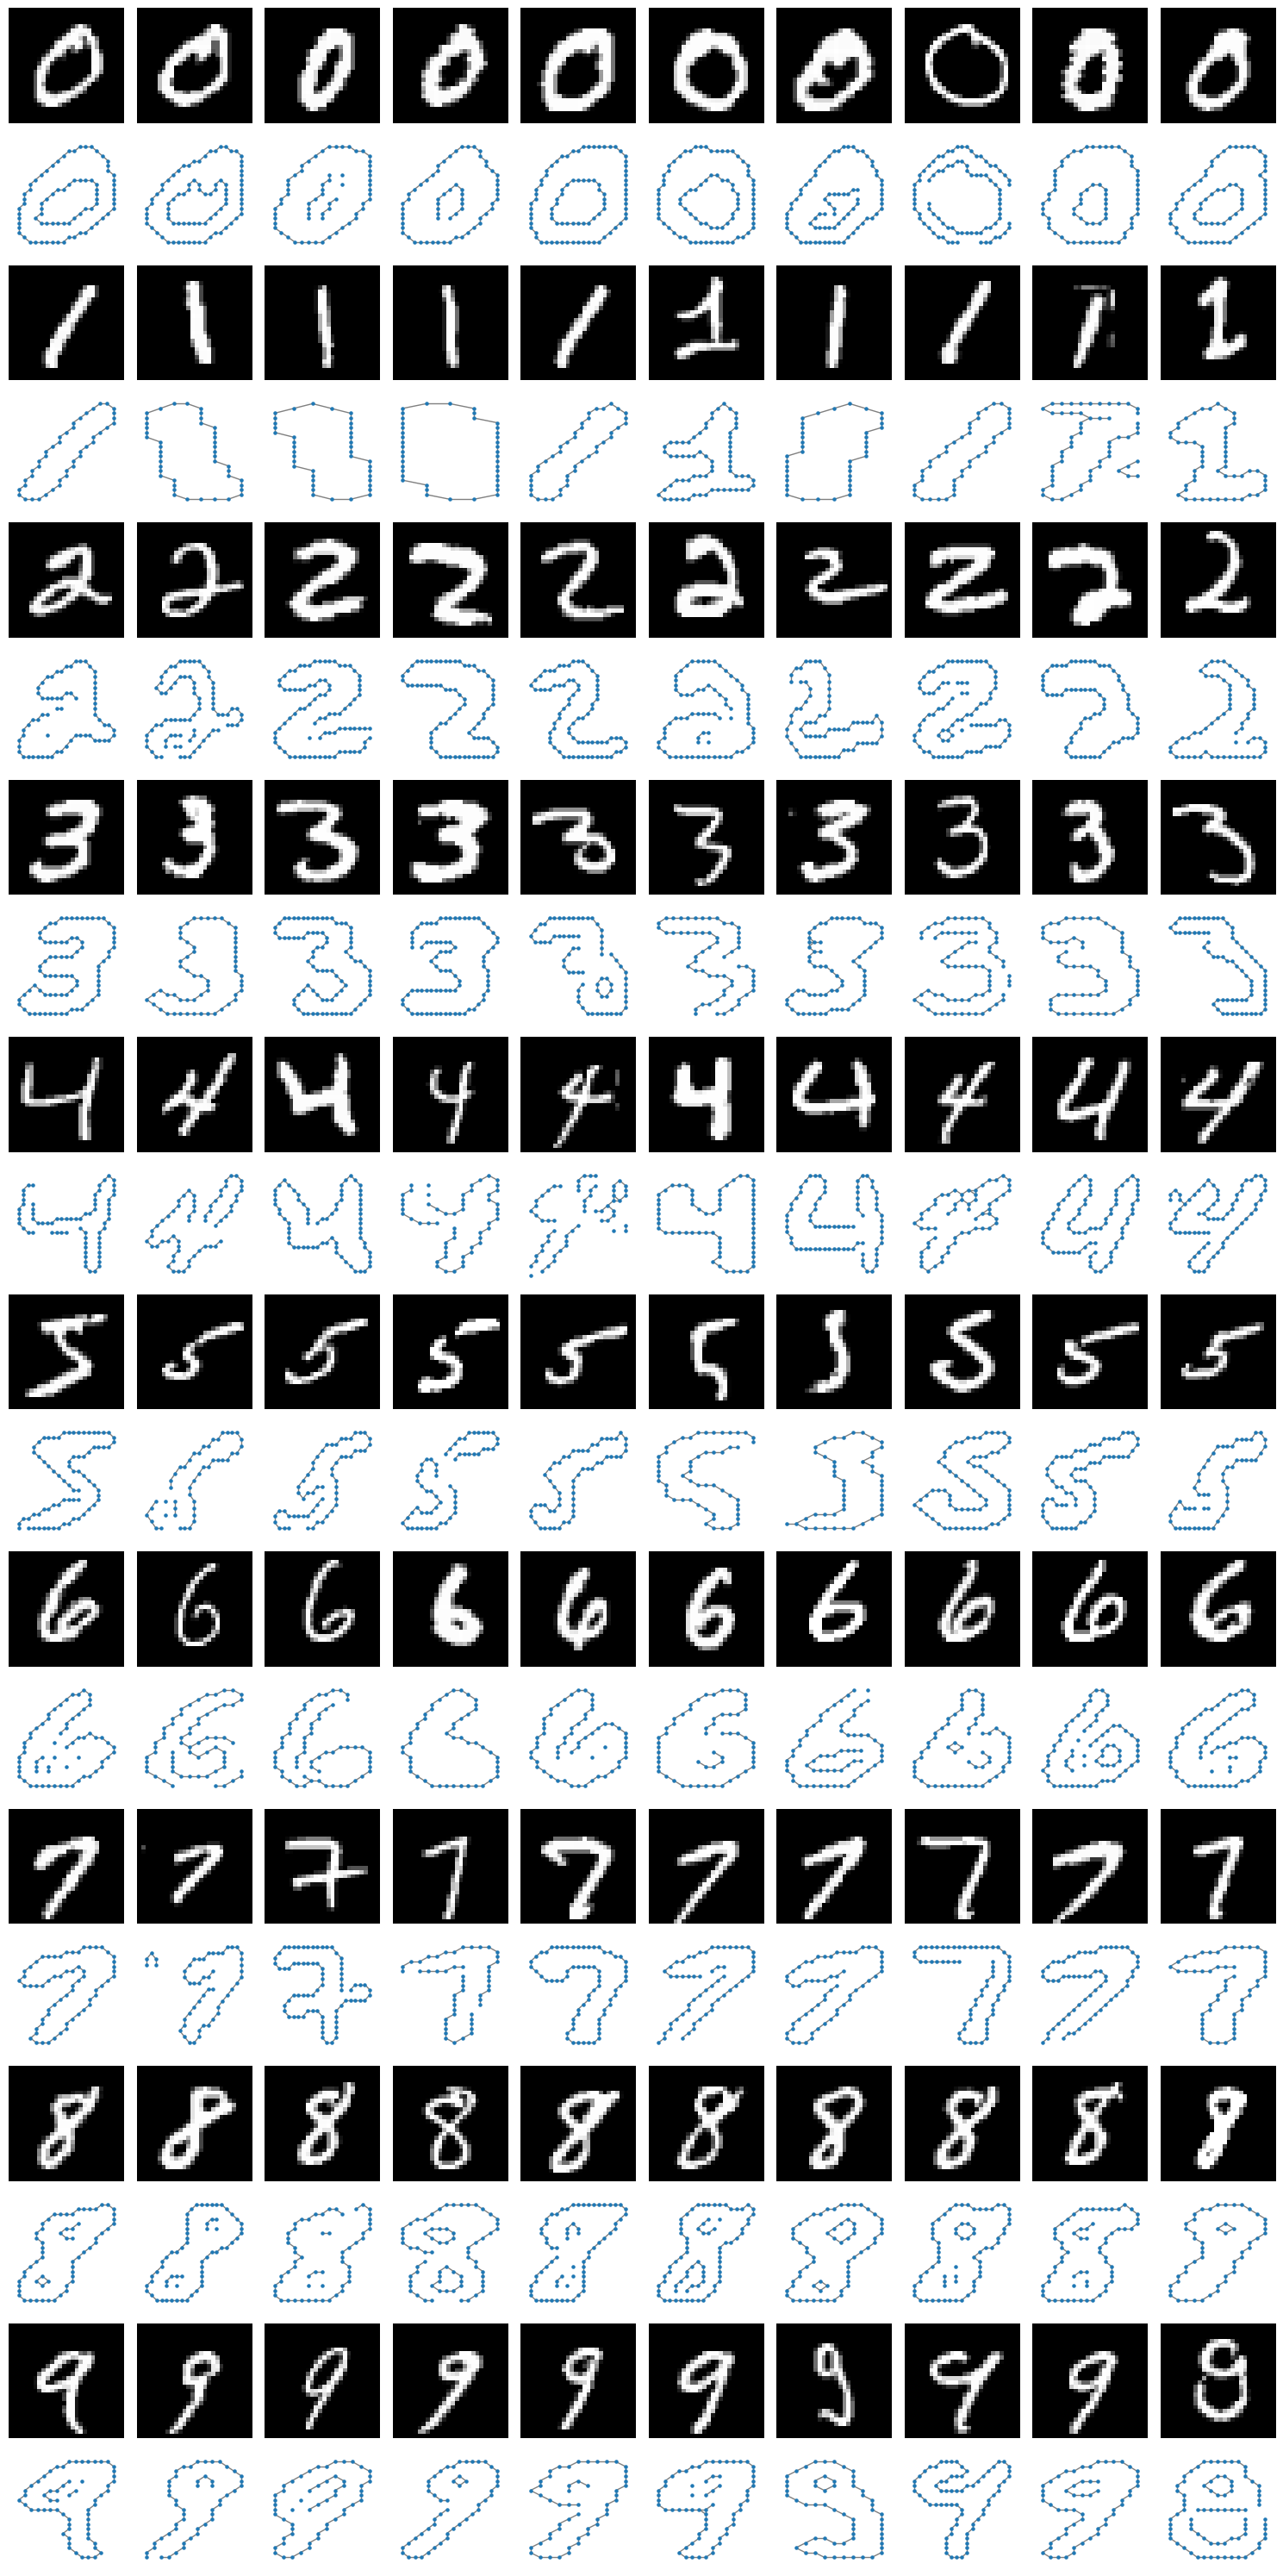

In [9]:
# Create a figure with 20 rows (10 digits, each with image + graph) and 10 columns
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
    
        ## second graph
        graph2 = mnist_to_graph(image)
        plot_graph(graph2, axes[2 * i + 1, j])

        axes[2 * i + 1, j].axis('off')



plt.tight_layout()
plt.show()

## 03. Merge edges with similar orientation

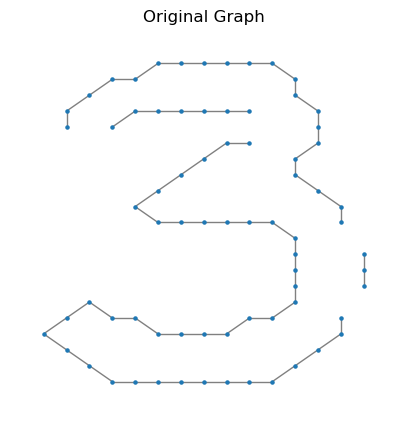

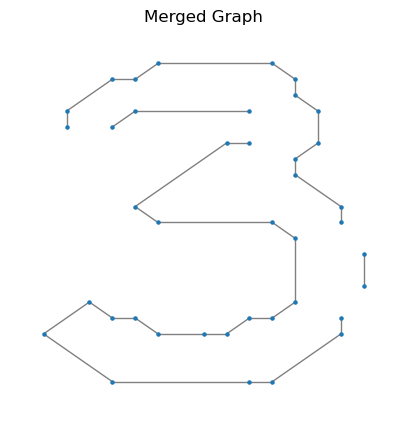

In [10]:
# Example usage (assuming skeleton image processing and graph creation as before)
image = x_train[y_train == 3][7]  # Get the first image of digit '3'
G = mnist_to_graph(image)

# Plot the original graph
fig, ax = plt.subplots(figsize=(5, 5))
plot_graph(G, ax)
plt.title("Original Graph")
plt.show()

# Merge edges with an angle threshold
G1 = merge_similar_edges(G, angle_threshold=30)

# Plot the merged graph
fig, ax = plt.subplots(figsize=(5, 5))
plot_graph(G1, ax)
plt.title("Merged Graph")
plt.show()

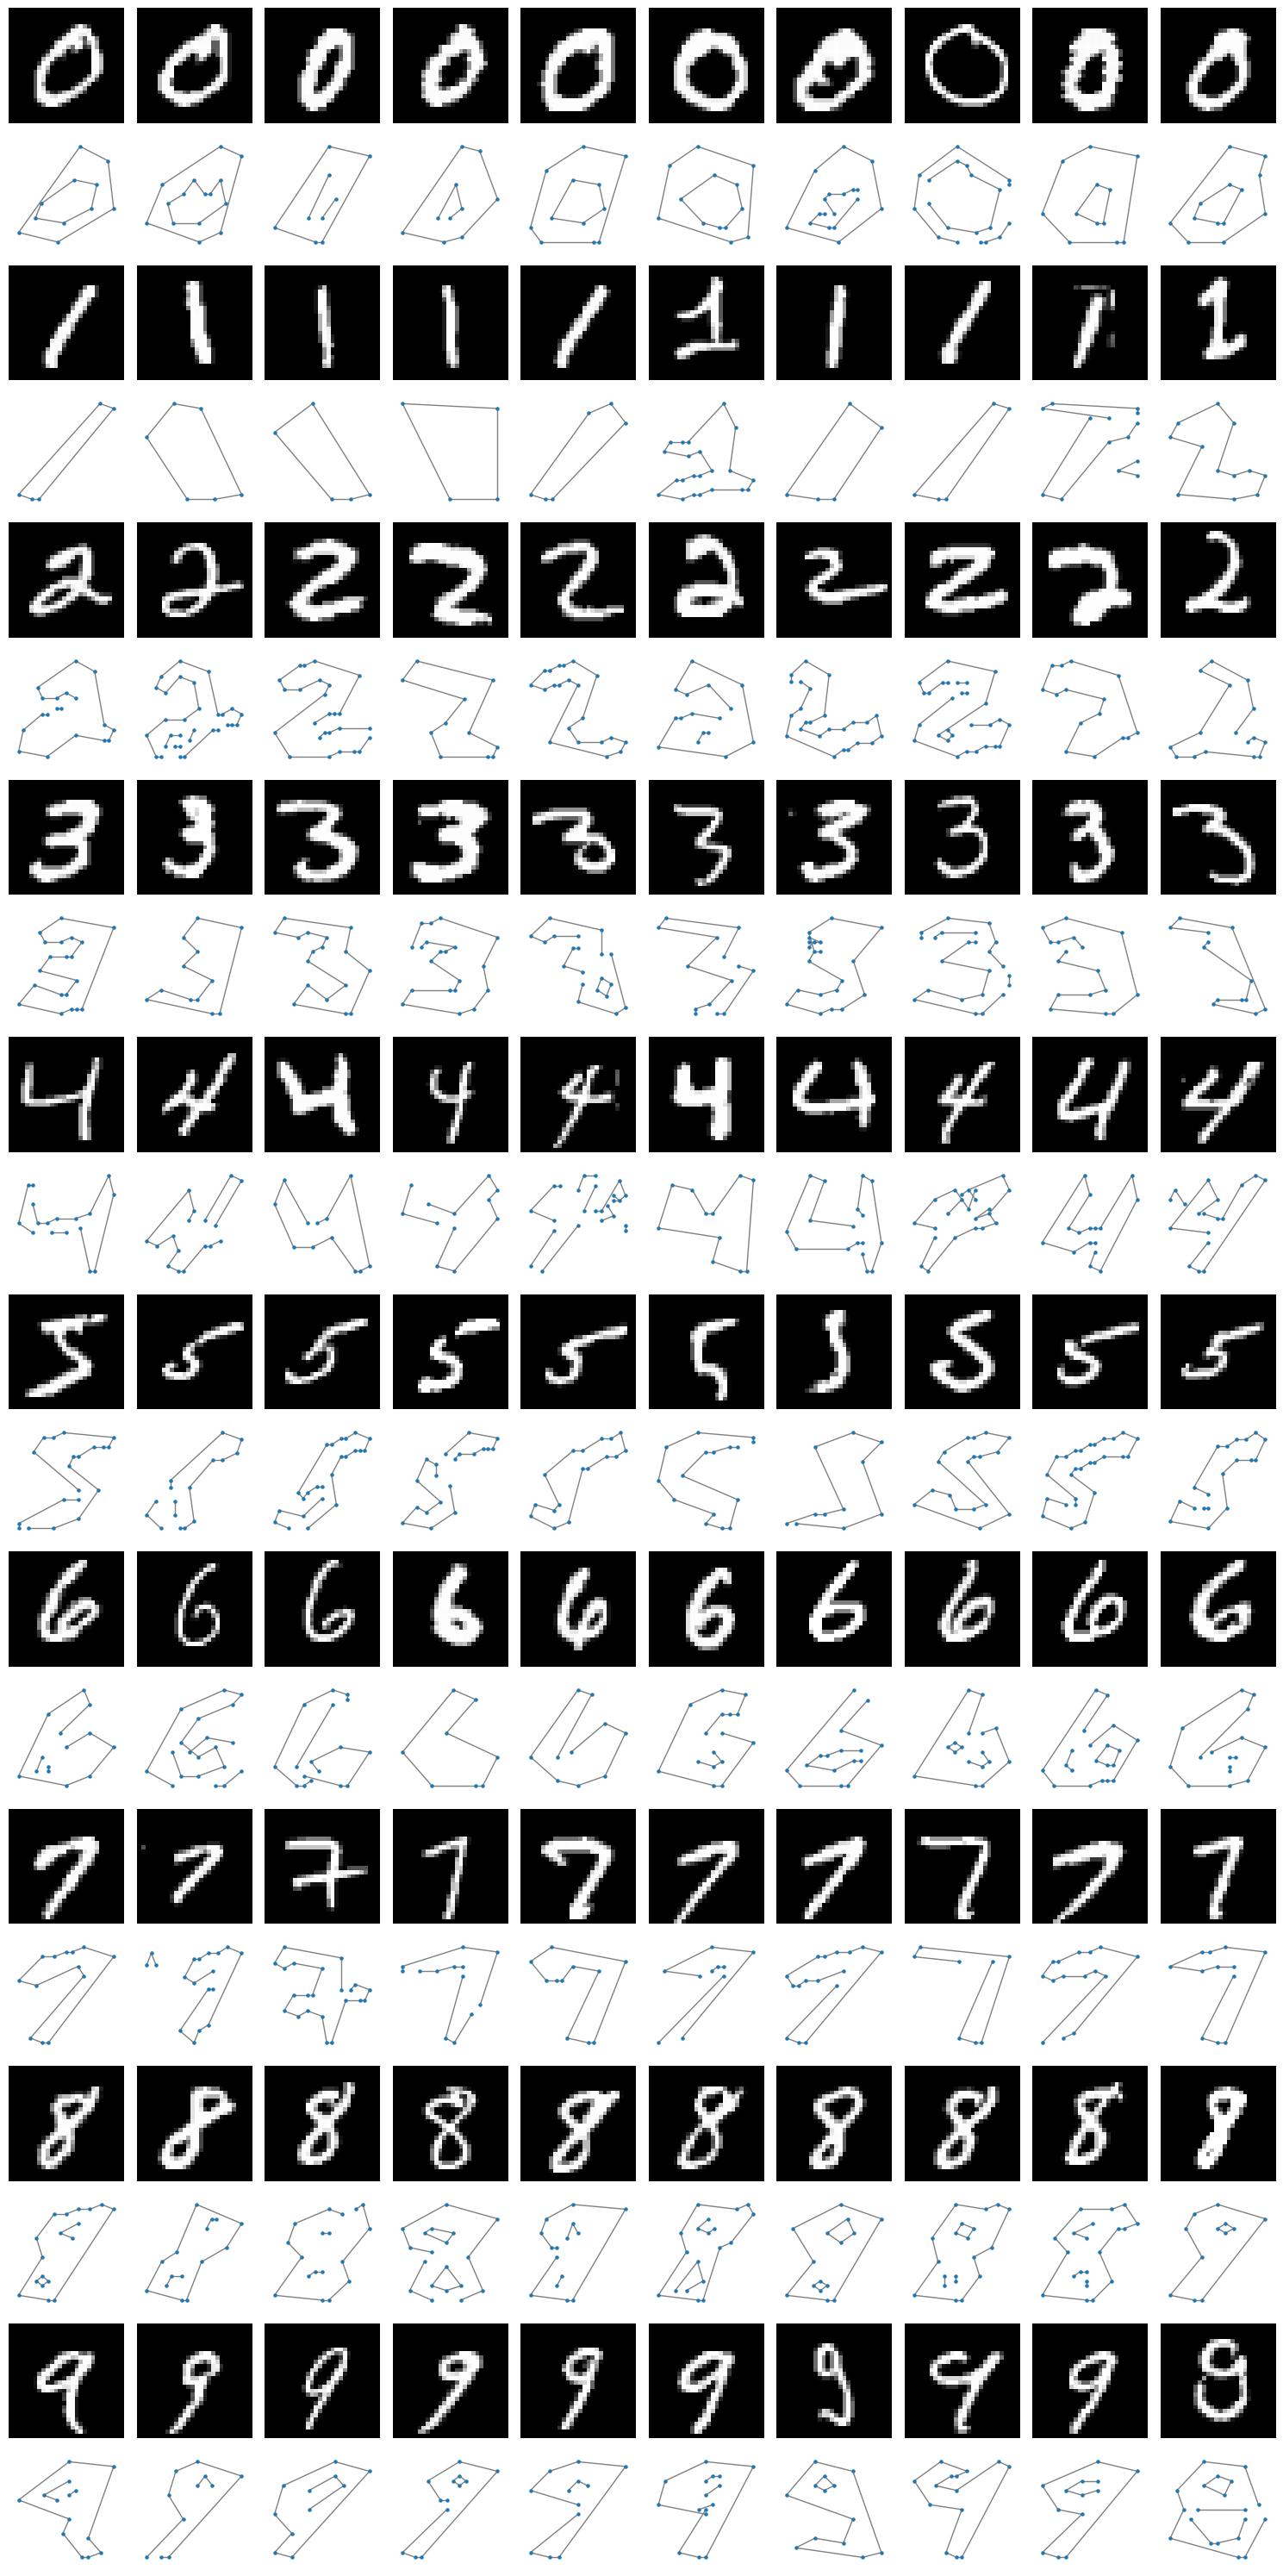

In [11]:
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
        
        G = mnist_to_graph(image)
        G = merge_similar_edges(G, angle_threshold=50)
        
        plot_graph(G, axes[2 * i + 1, j])
        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()

## 04. Lets detect bezier curves 

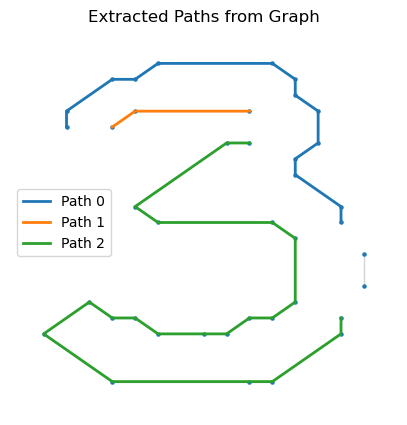

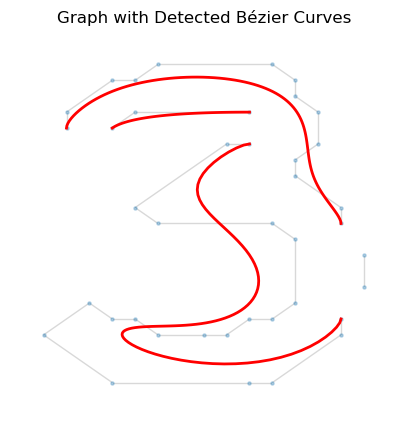

In [23]:
# Assuming merged_G is your graph, extract paths from it
image = x_train[y_train == 3][7]  # Get the first image of digit '3'

G = mnist_to_graph(image)
G1 = merge_similar_edges(G, angle_threshold=30)
paths = extract_long_paths(G1)#, min_length=5)

# Display extracted paths 
fig, ax = plt.subplots(figsize=(5, 5))

# Draw the full graph in light gray
nx.draw(G1, pos={node: node for node in G1.nodes()}, 
        node_size=5, edge_color='lightgray', ax=ax)

# Overlay each path in a different color
for i, path in enumerate(paths):
    path_x = [node[0] for node in path]
    path_y = [node[1] for node in path]
    ax.plot(path_x, path_y, label=f'Path {i}', linewidth=2)

plt.title("Extracted Paths from Graph")
plt.legend()
plt.show()


# Number of nodes to sample from each path
num_sampled_nodes = 10

# Now fit Bézier curves to these paths and visualize
fig, ax = plt.subplots(figsize=(5, 5))

# Plot the original graph
# Draw the entire graph in light gray
pos = {node: node for node in G1.nodes()}  # Node positions
nx.draw(G1, pos, node_size=5, edge_color='gray', alpha=0.3, ax=ax)

# Loop through the paths and fit Bézier curves
for path in paths:
    # Sample a subset of nodes from the path (for example, 10 nodes)
    # sampled_path = sample_nodes_from_path(path, num_sampled_nodes)

    curve, control_points = fit_bezier_curve(path)  # Fit Bézier curve to the path
    bezier_x, bezier_y = get_bezier_curve_points(curve)  # Get the curve points

    # Plot the fitted Bézier curve
    plt.plot(bezier_x, bezier_y, label="Detected Curve", color="red", linewidth=2)

# Show the plot with Bézier curves
plt.title("Graph with Detected Bézier Curves")
plt.show()

### Bezier curves for digit = $3$ and for different min length paths = $[7, 5, 2]$

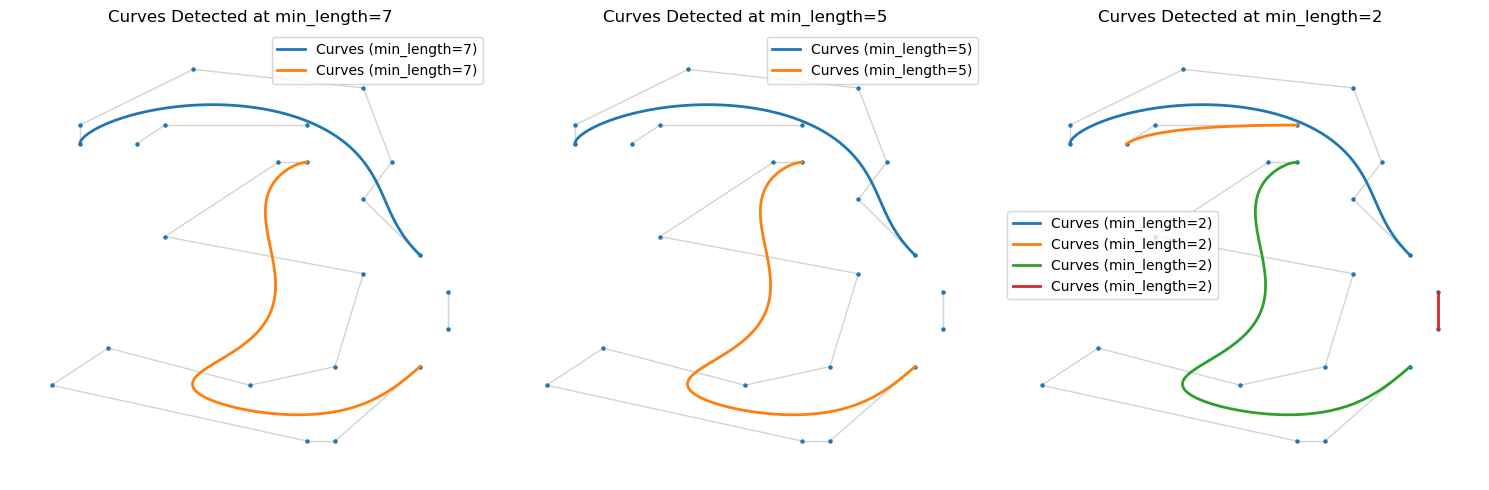

In [13]:
# extract for 3 
image = x_train[y_train  == 3][7]
G = mnist_to_graph(image)
G1 = merge_similar_edges(G, angle_threshold=50)

# Assuming G1 is your graph, extract and display curves at different sensitivity levels
identify_and_display_curves(G1, min_length_values=[7, 5, 2])

### Bezier curves for digit = $3$ and for different min length paths = $[7, 5, 2]$ and angles = $[0, 10, 50, 70]$

Digit 2: Curves detected at angle threshold = 0.


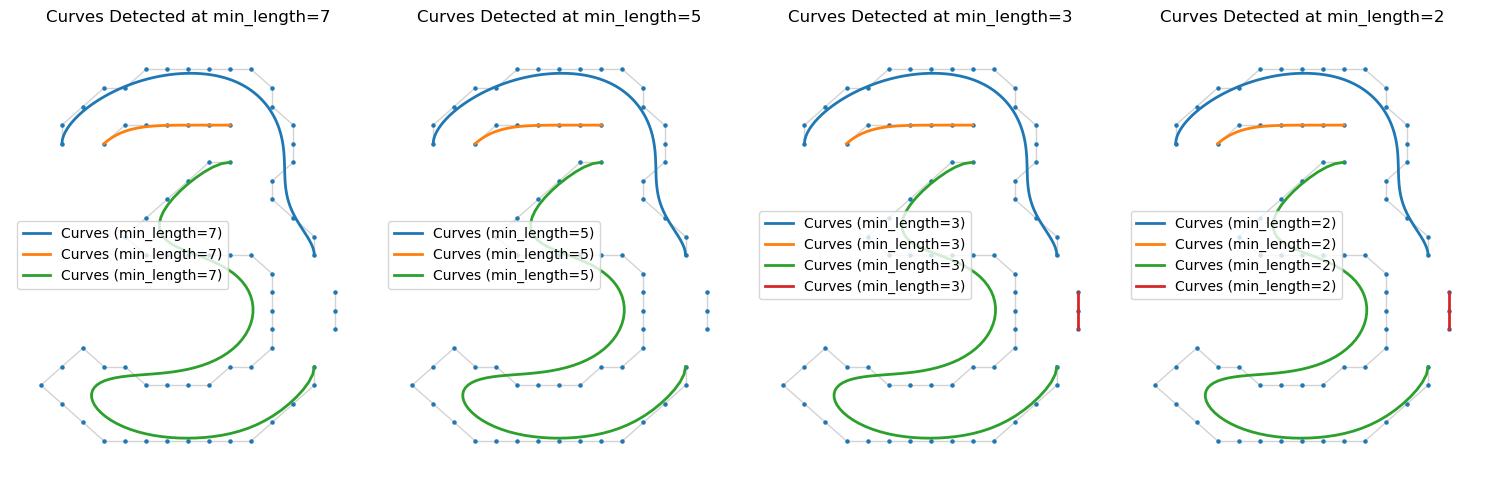

Digit 2: Curves detected at angle threshold = 10.


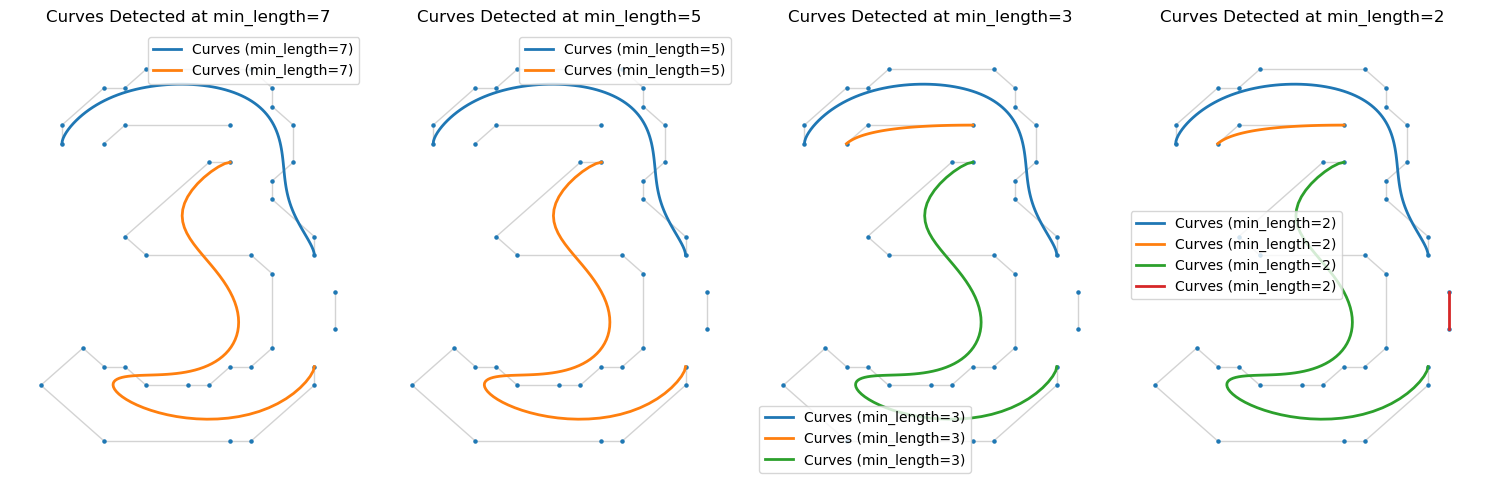

Digit 2: Curves detected at angle threshold = 50.


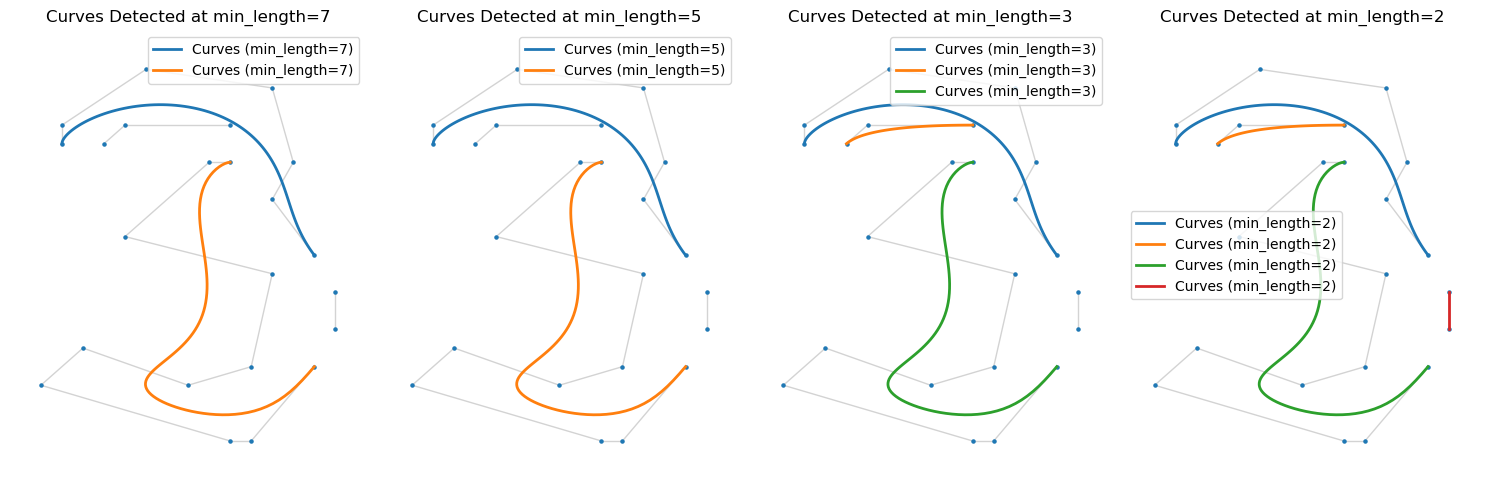

Digit 2: Curves detected at angle threshold = 70.


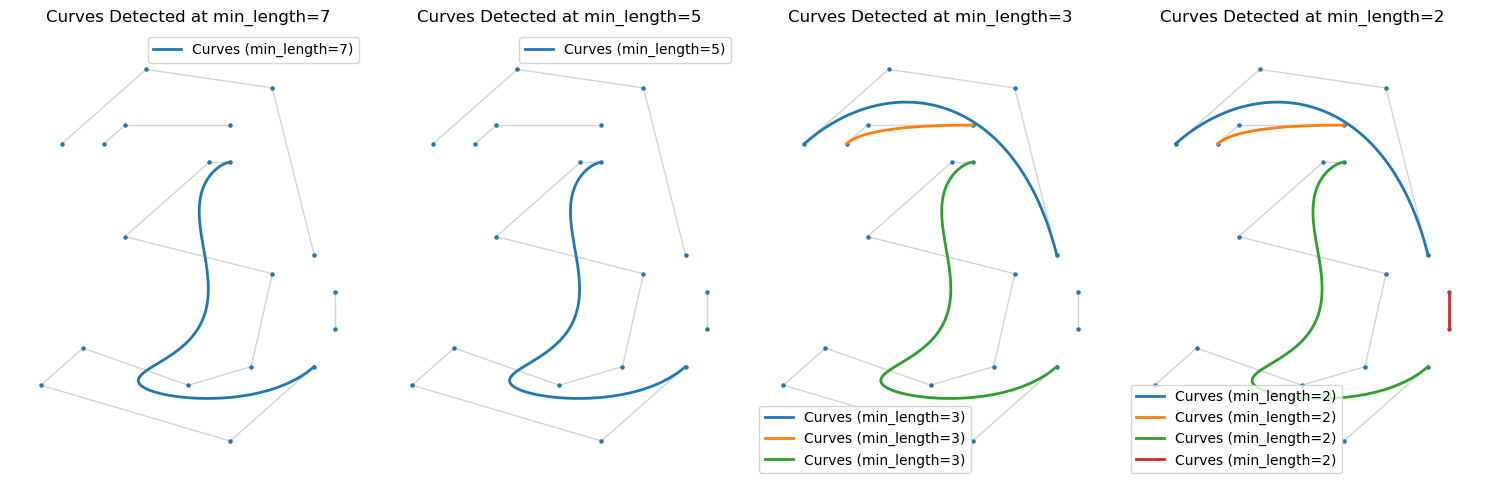

In [14]:
# For different smoothing levels
angle_thresholds = [0, 10, 50, 70]
for angle in angle_thresholds:
    print(f"Digit {i}: Curves detected at angle threshold = {angle}.")
    # Get the first image of digit i
    image = x_train[y_train == 3][7]
    
    # Preprocess the image and extract the graph
    G = mnist_to_graph(image)
    G = merge_similar_edges(G, angle_threshold=angle)
    
    # Identify and display curves
    identify_and_display_curves(G, min_length_values=[7, 5, 3, 2])

## smoothing_angle = $30$
### Bezier curves for different digits and for different min length paths = $[7, 5, 2]$

/Users/ewamiazga/Desktop/studies/AILAB/ai-lab-work/graph_based_codebase.py:247: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


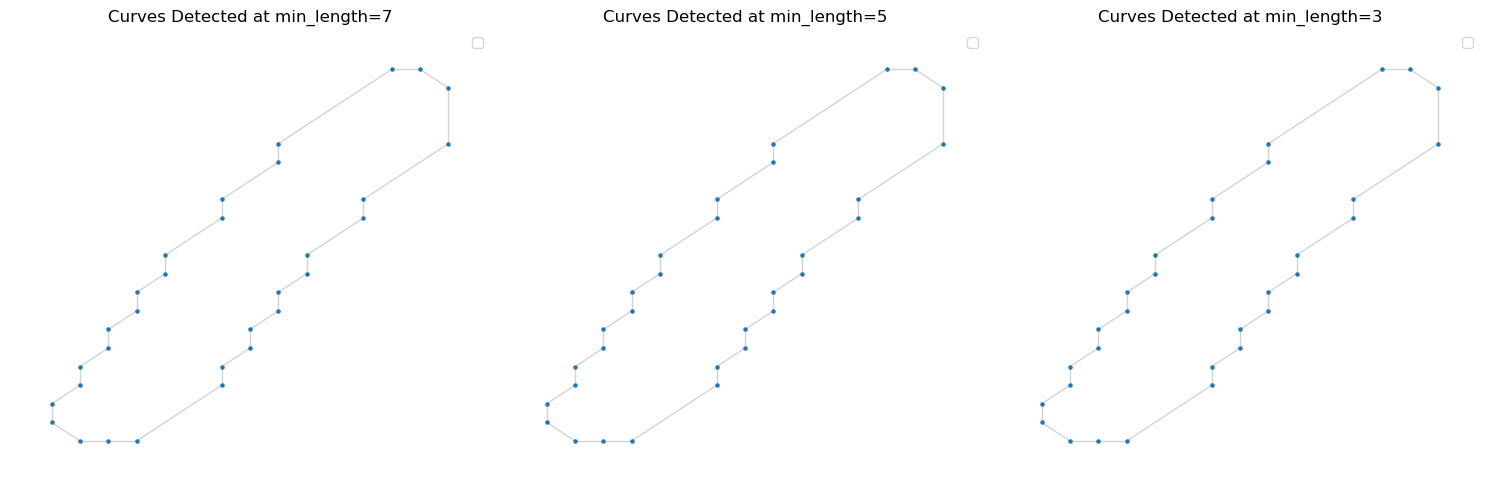

Digit 1: Curves detected at different sensitivity levels.


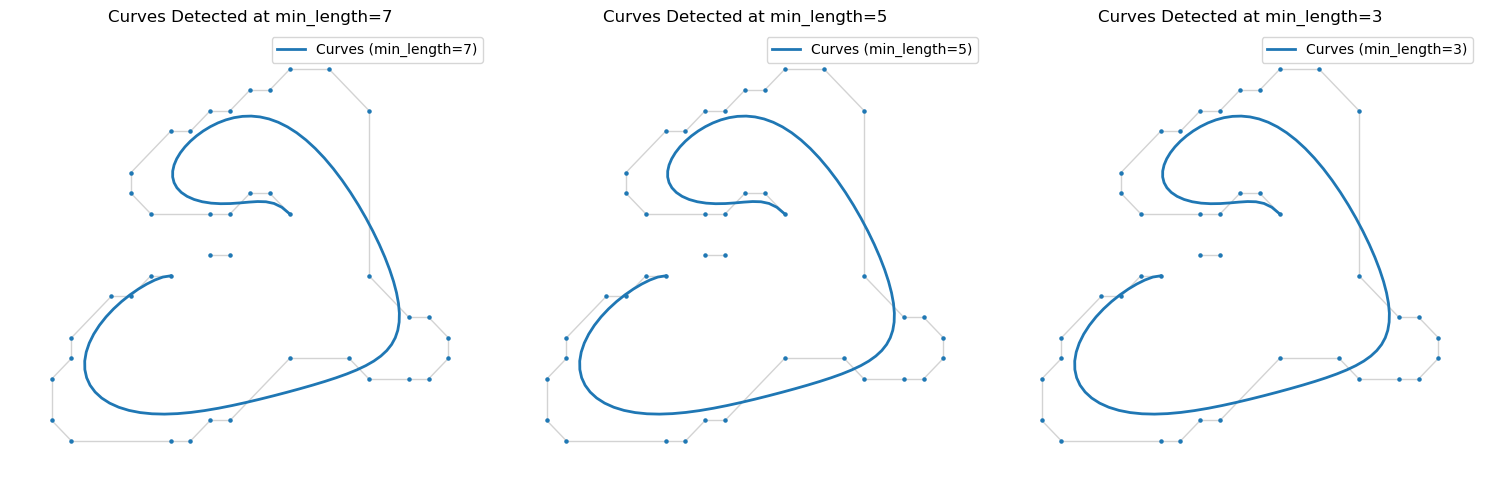

Digit 2: Curves detected at different sensitivity levels.


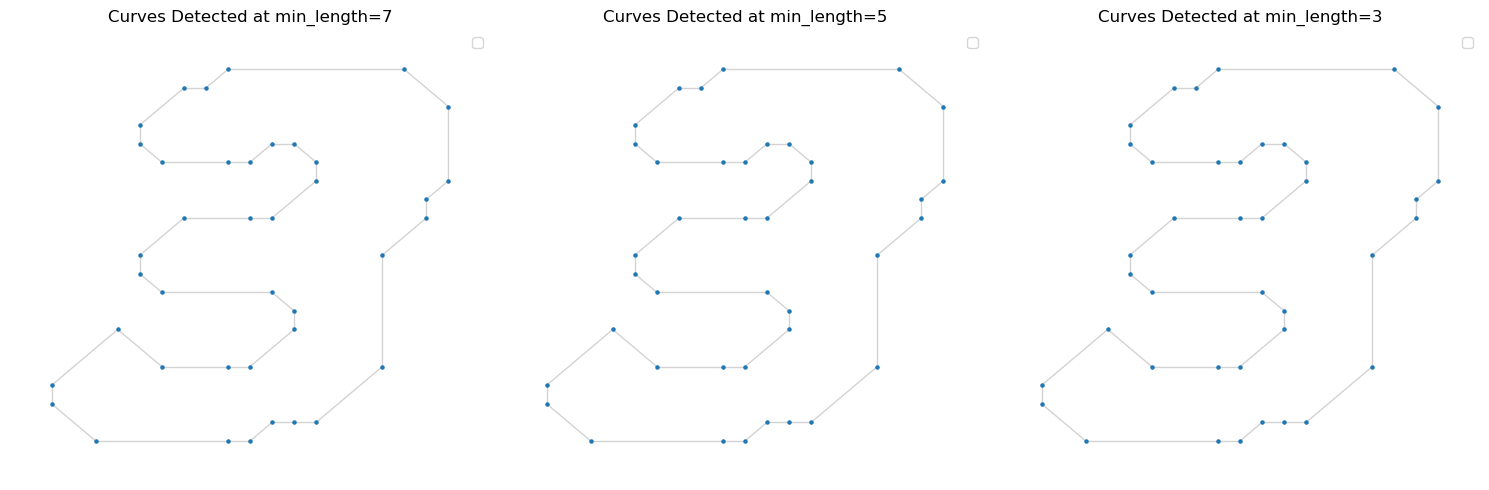

Digit 3: Curves detected at different sensitivity levels.


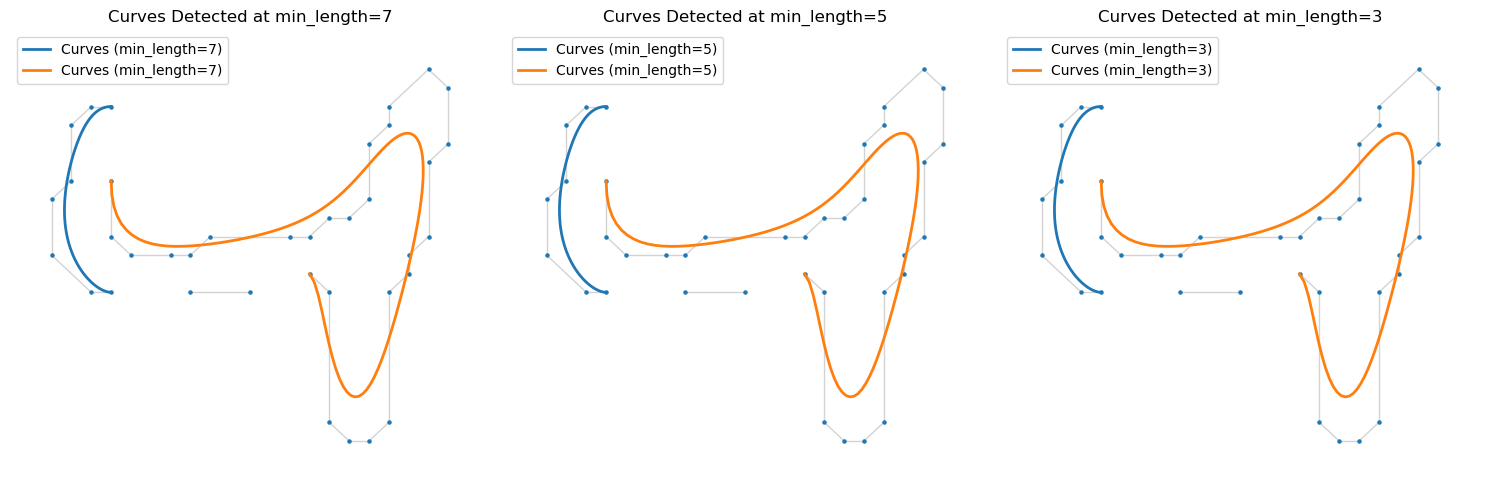

Digit 4: Curves detected at different sensitivity levels.


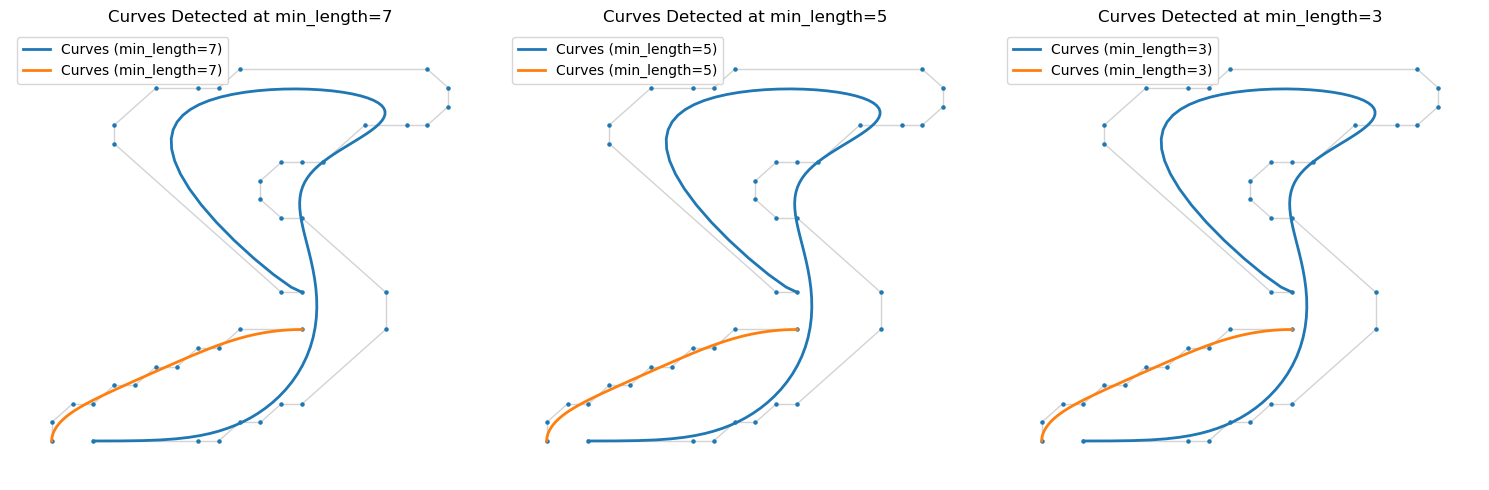

Digit 5: Curves detected at different sensitivity levels.


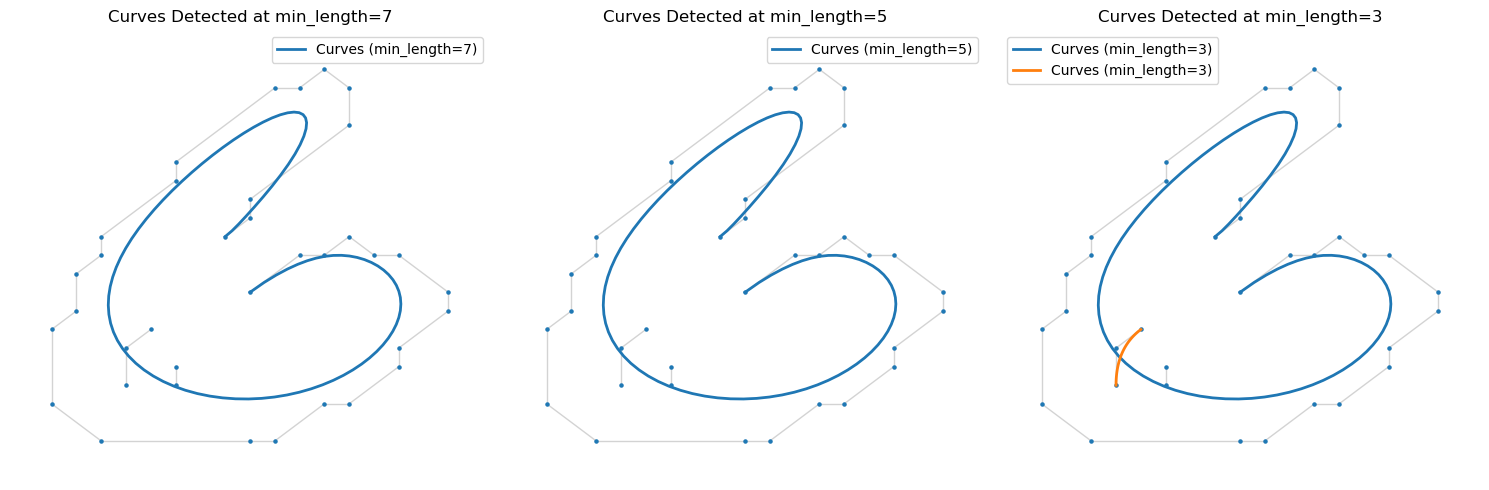

Digit 6: Curves detected at different sensitivity levels.


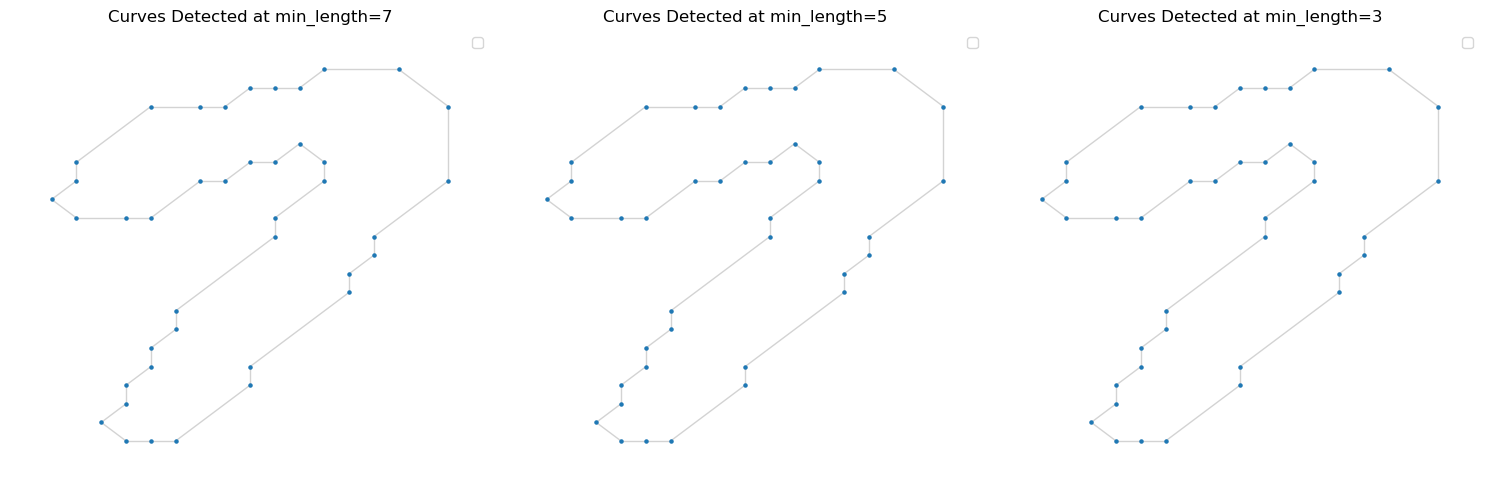

Digit 7: Curves detected at different sensitivity levels.


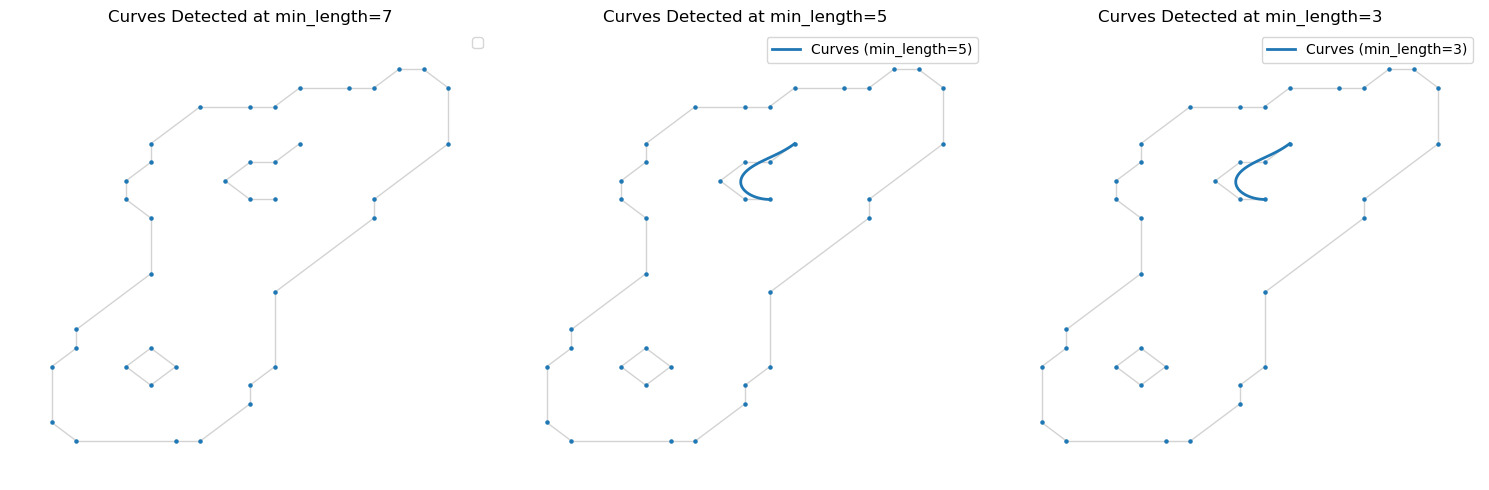

Digit 8: Curves detected at different sensitivity levels.


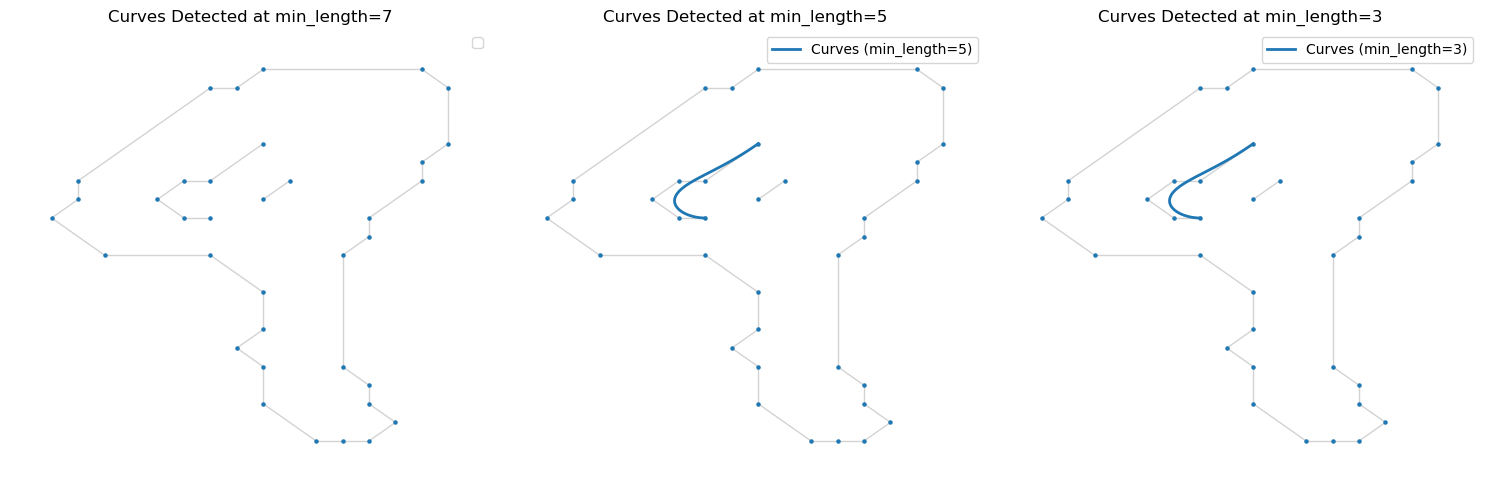

Digit 9: Curves detected at different sensitivity levels.


In [15]:
for i in range(1, 10):
    # Get the first image of digit i
    image = x_train[y_train == i][0]
    
    # Preprocess the image and extract the graph
    G = mnist_to_graph(image)
    G = merge_similar_edges(G, angle_threshold=30)
    
    # Identify and display curves
    identify_and_display_curves(G, min_length_values=[7, 5, 3])
    
    print(f"Digit {i}: Curves detected at different sensitivity levels.")

## smoothing_angle = $50$
### Bezier curves for different digits and for different min length paths = $[7, 5, 2]$

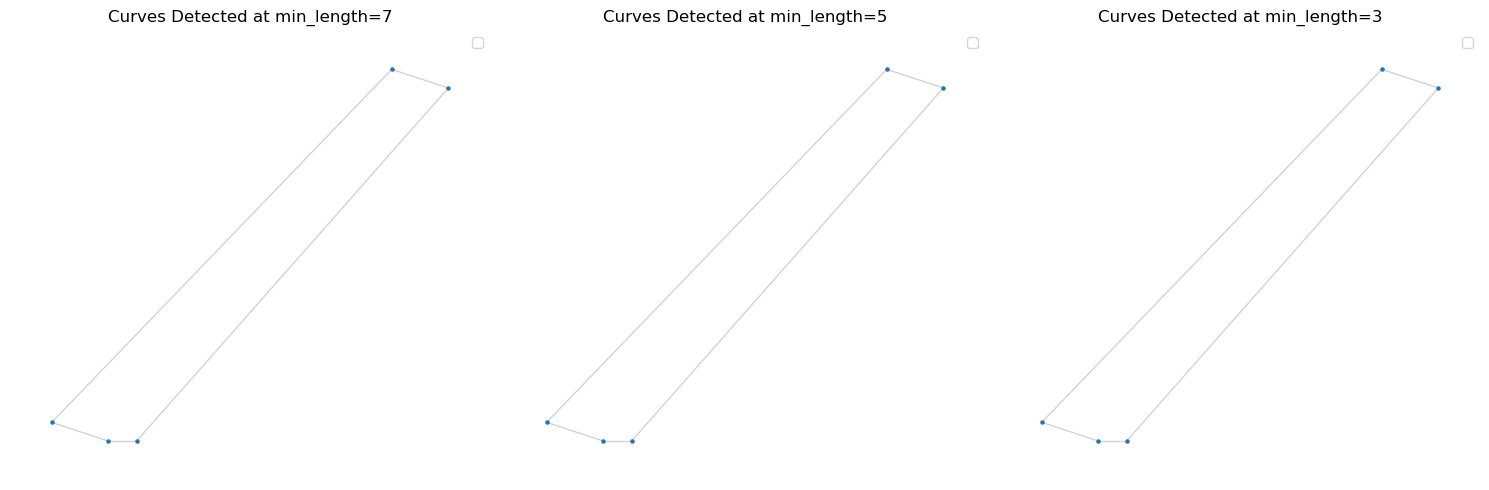

Digit 1: Curves detected at different sensitivity levels.


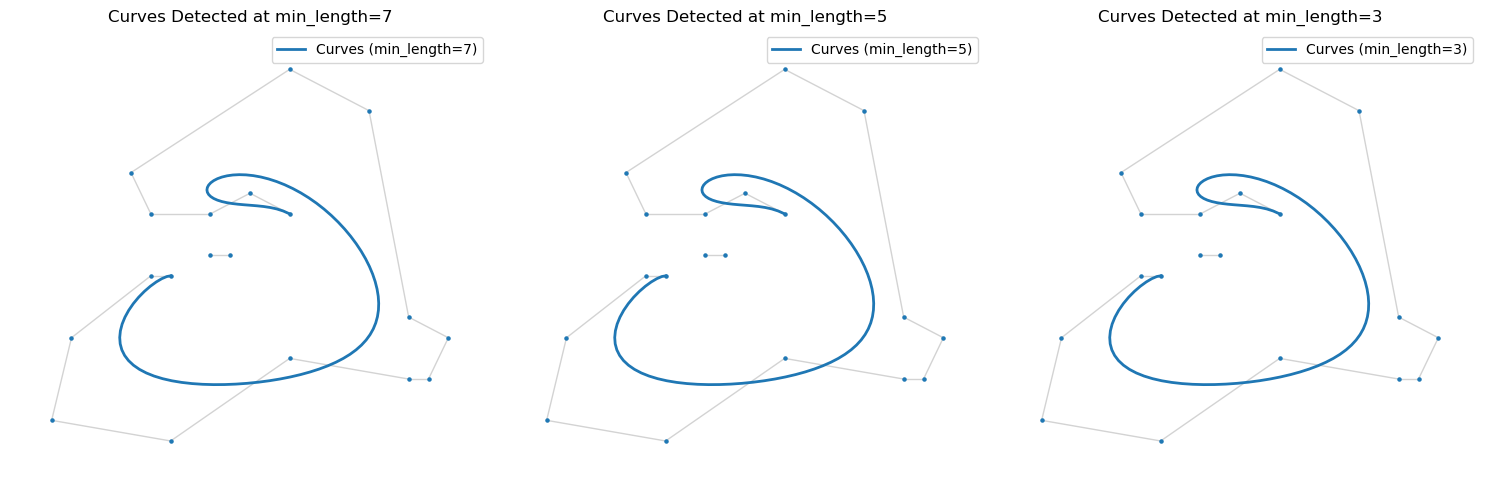

Digit 2: Curves detected at different sensitivity levels.


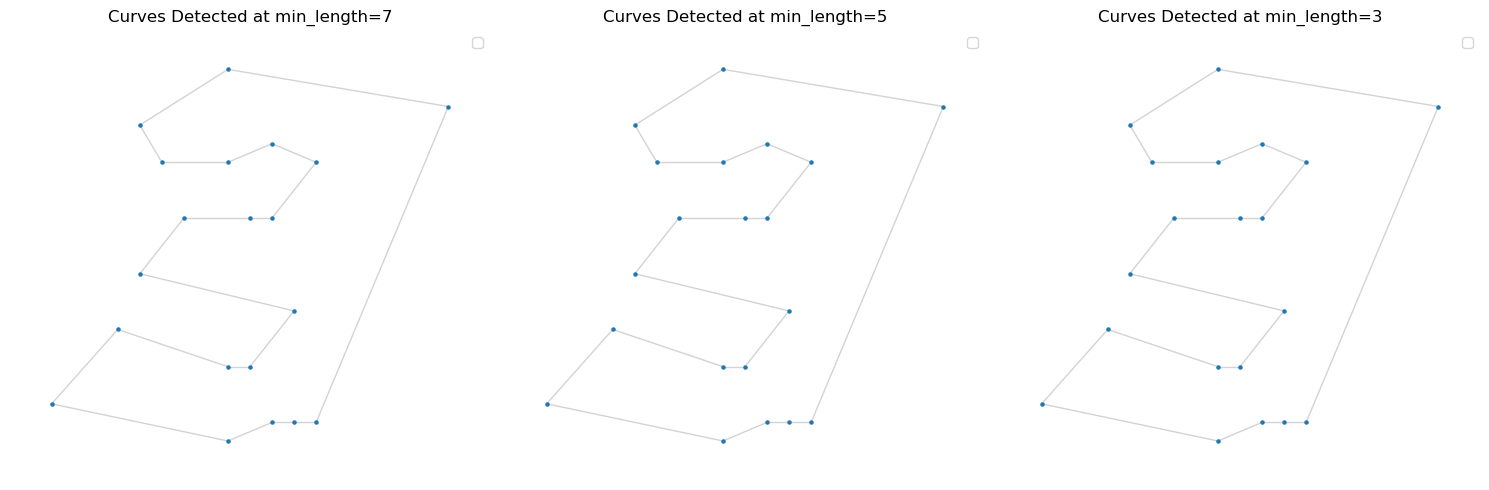

Digit 3: Curves detected at different sensitivity levels.


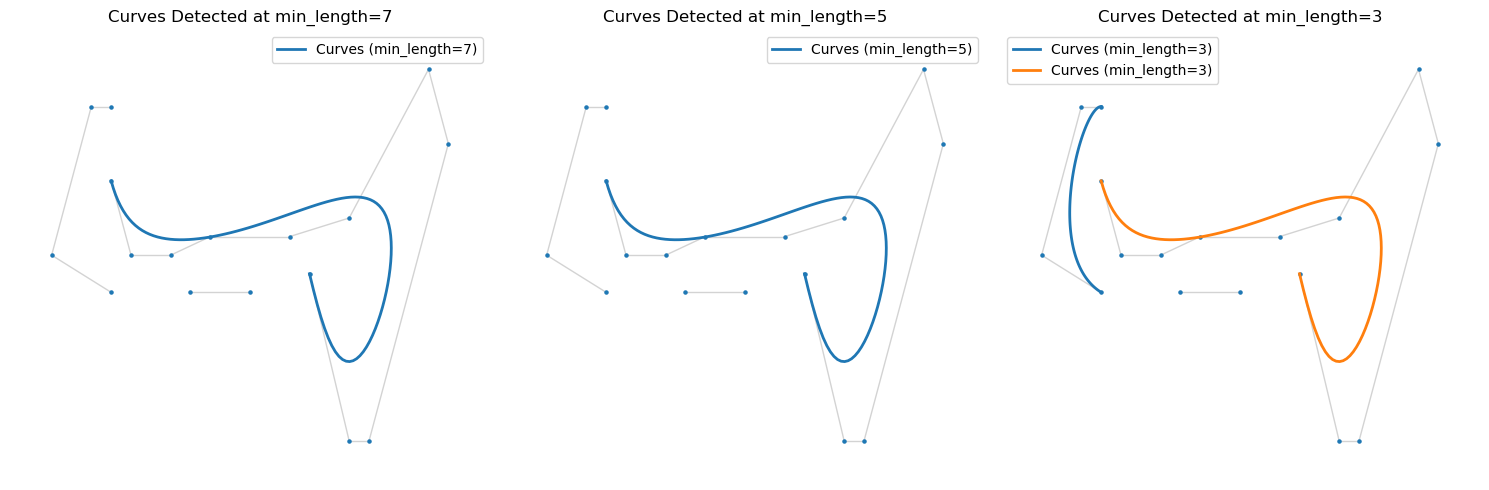

Digit 4: Curves detected at different sensitivity levels.


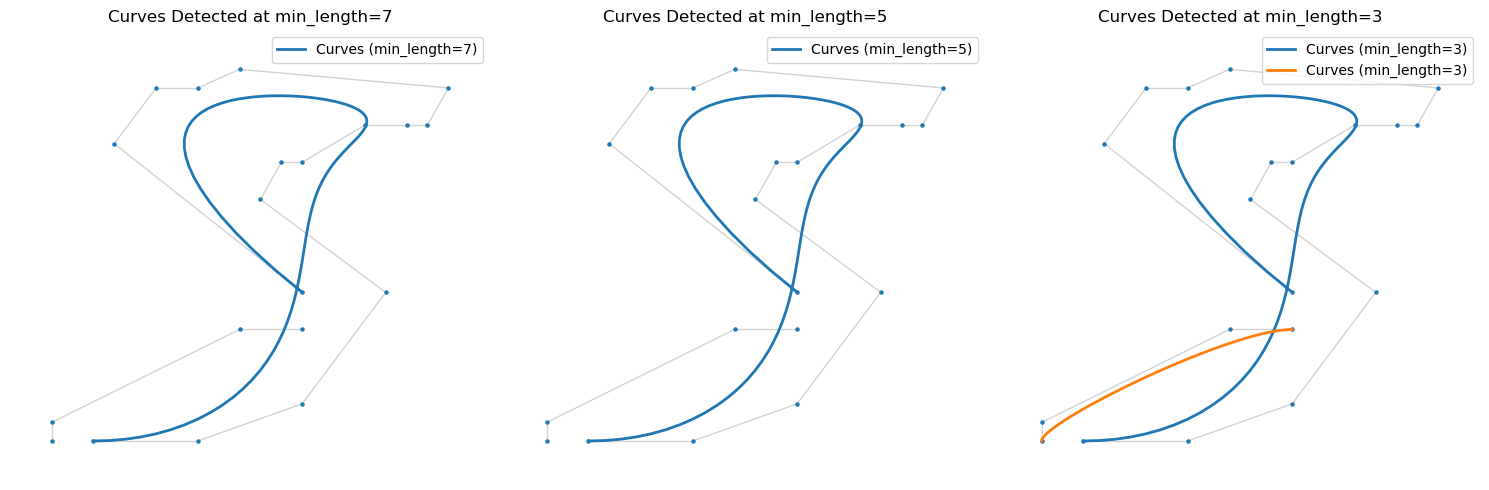

Digit 5: Curves detected at different sensitivity levels.


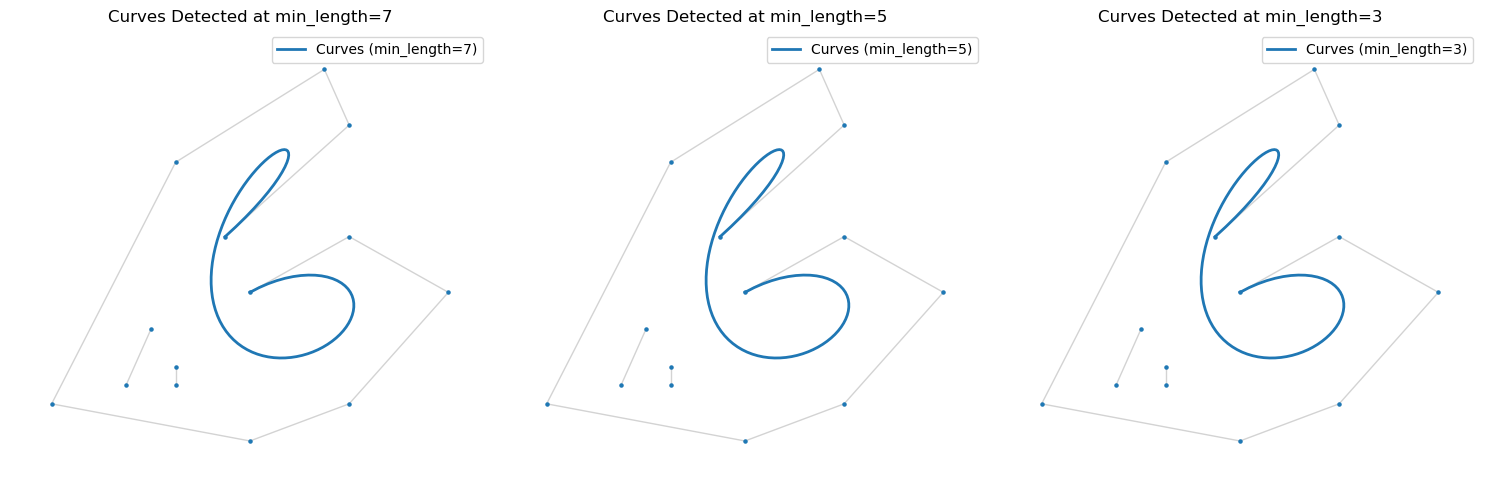

Digit 6: Curves detected at different sensitivity levels.


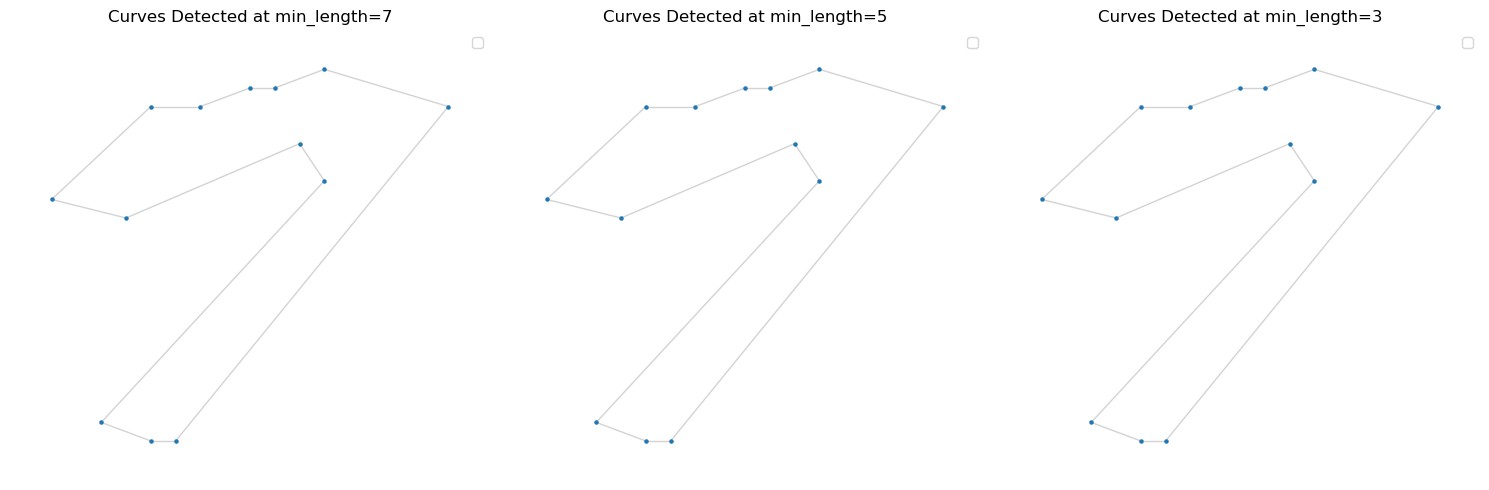

Digit 7: Curves detected at different sensitivity levels.


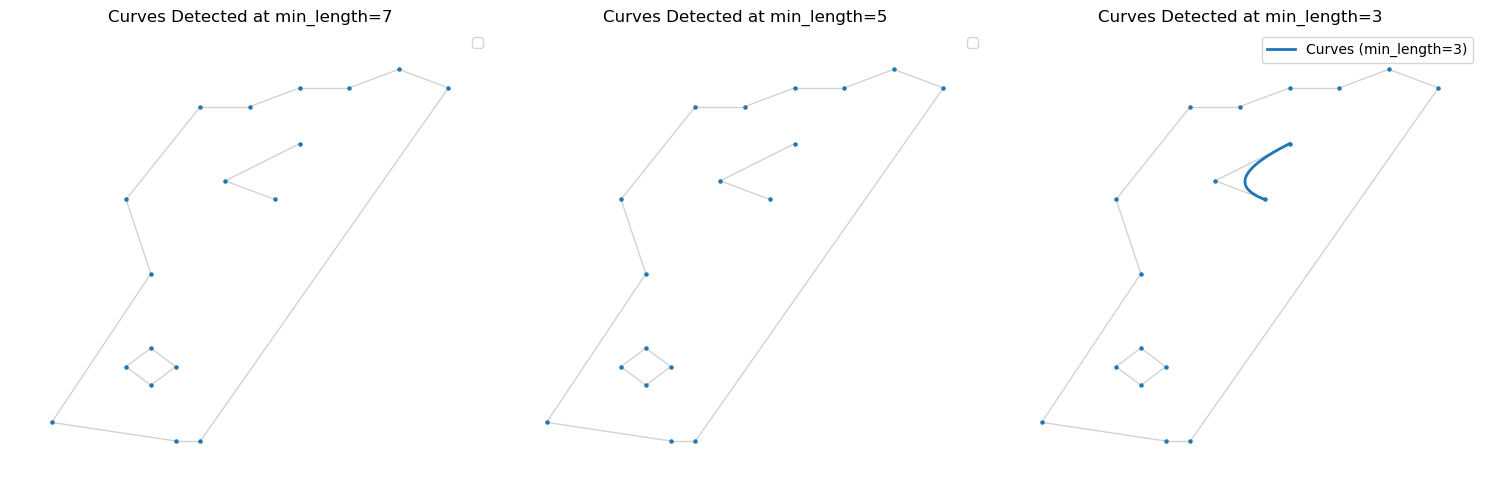

Digit 8: Curves detected at different sensitivity levels.


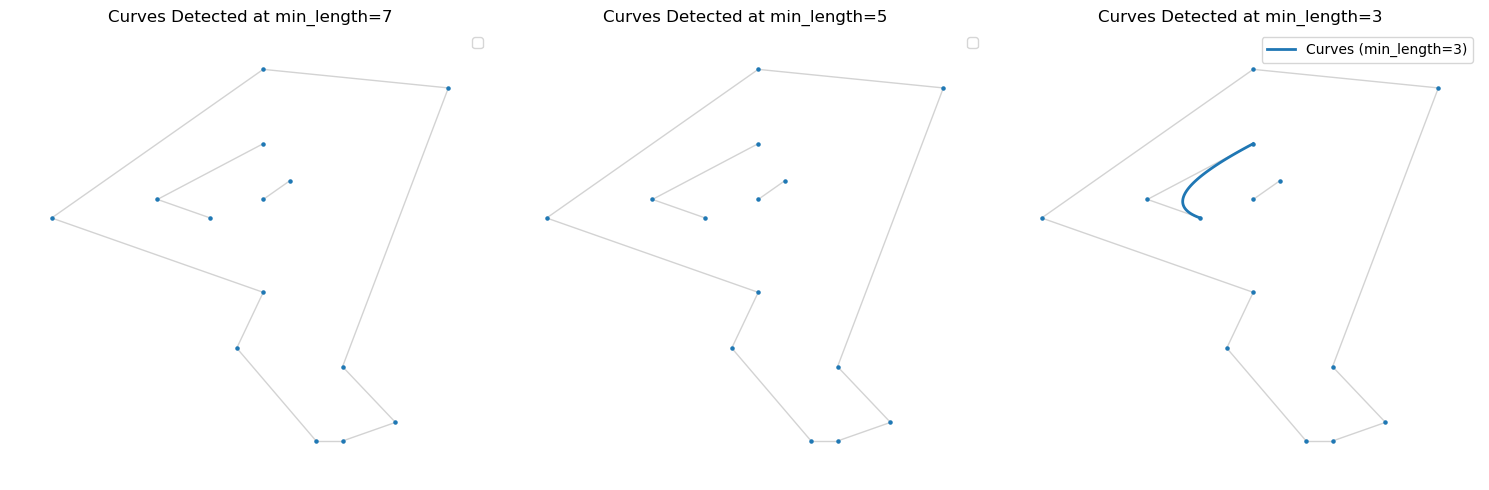

Digit 9: Curves detected at different sensitivity levels.


In [16]:
for i in range(1, 10):
    # Get the first image of digit i
    image = x_train[y_train == i][0]
    
    # Preprocess the image and extract the graph
    G = mnist_to_graph(image)
    G = merge_similar_edges(G, angle_threshold=50)
    
    # Identify and display curves
    identify_and_display_curves(G, min_length_values=[7, 5, 3])
    
    print(f"Digit {i}: Curves detected at different sensitivity levels.")

### Fast bezier curve fitting - does not perform so well

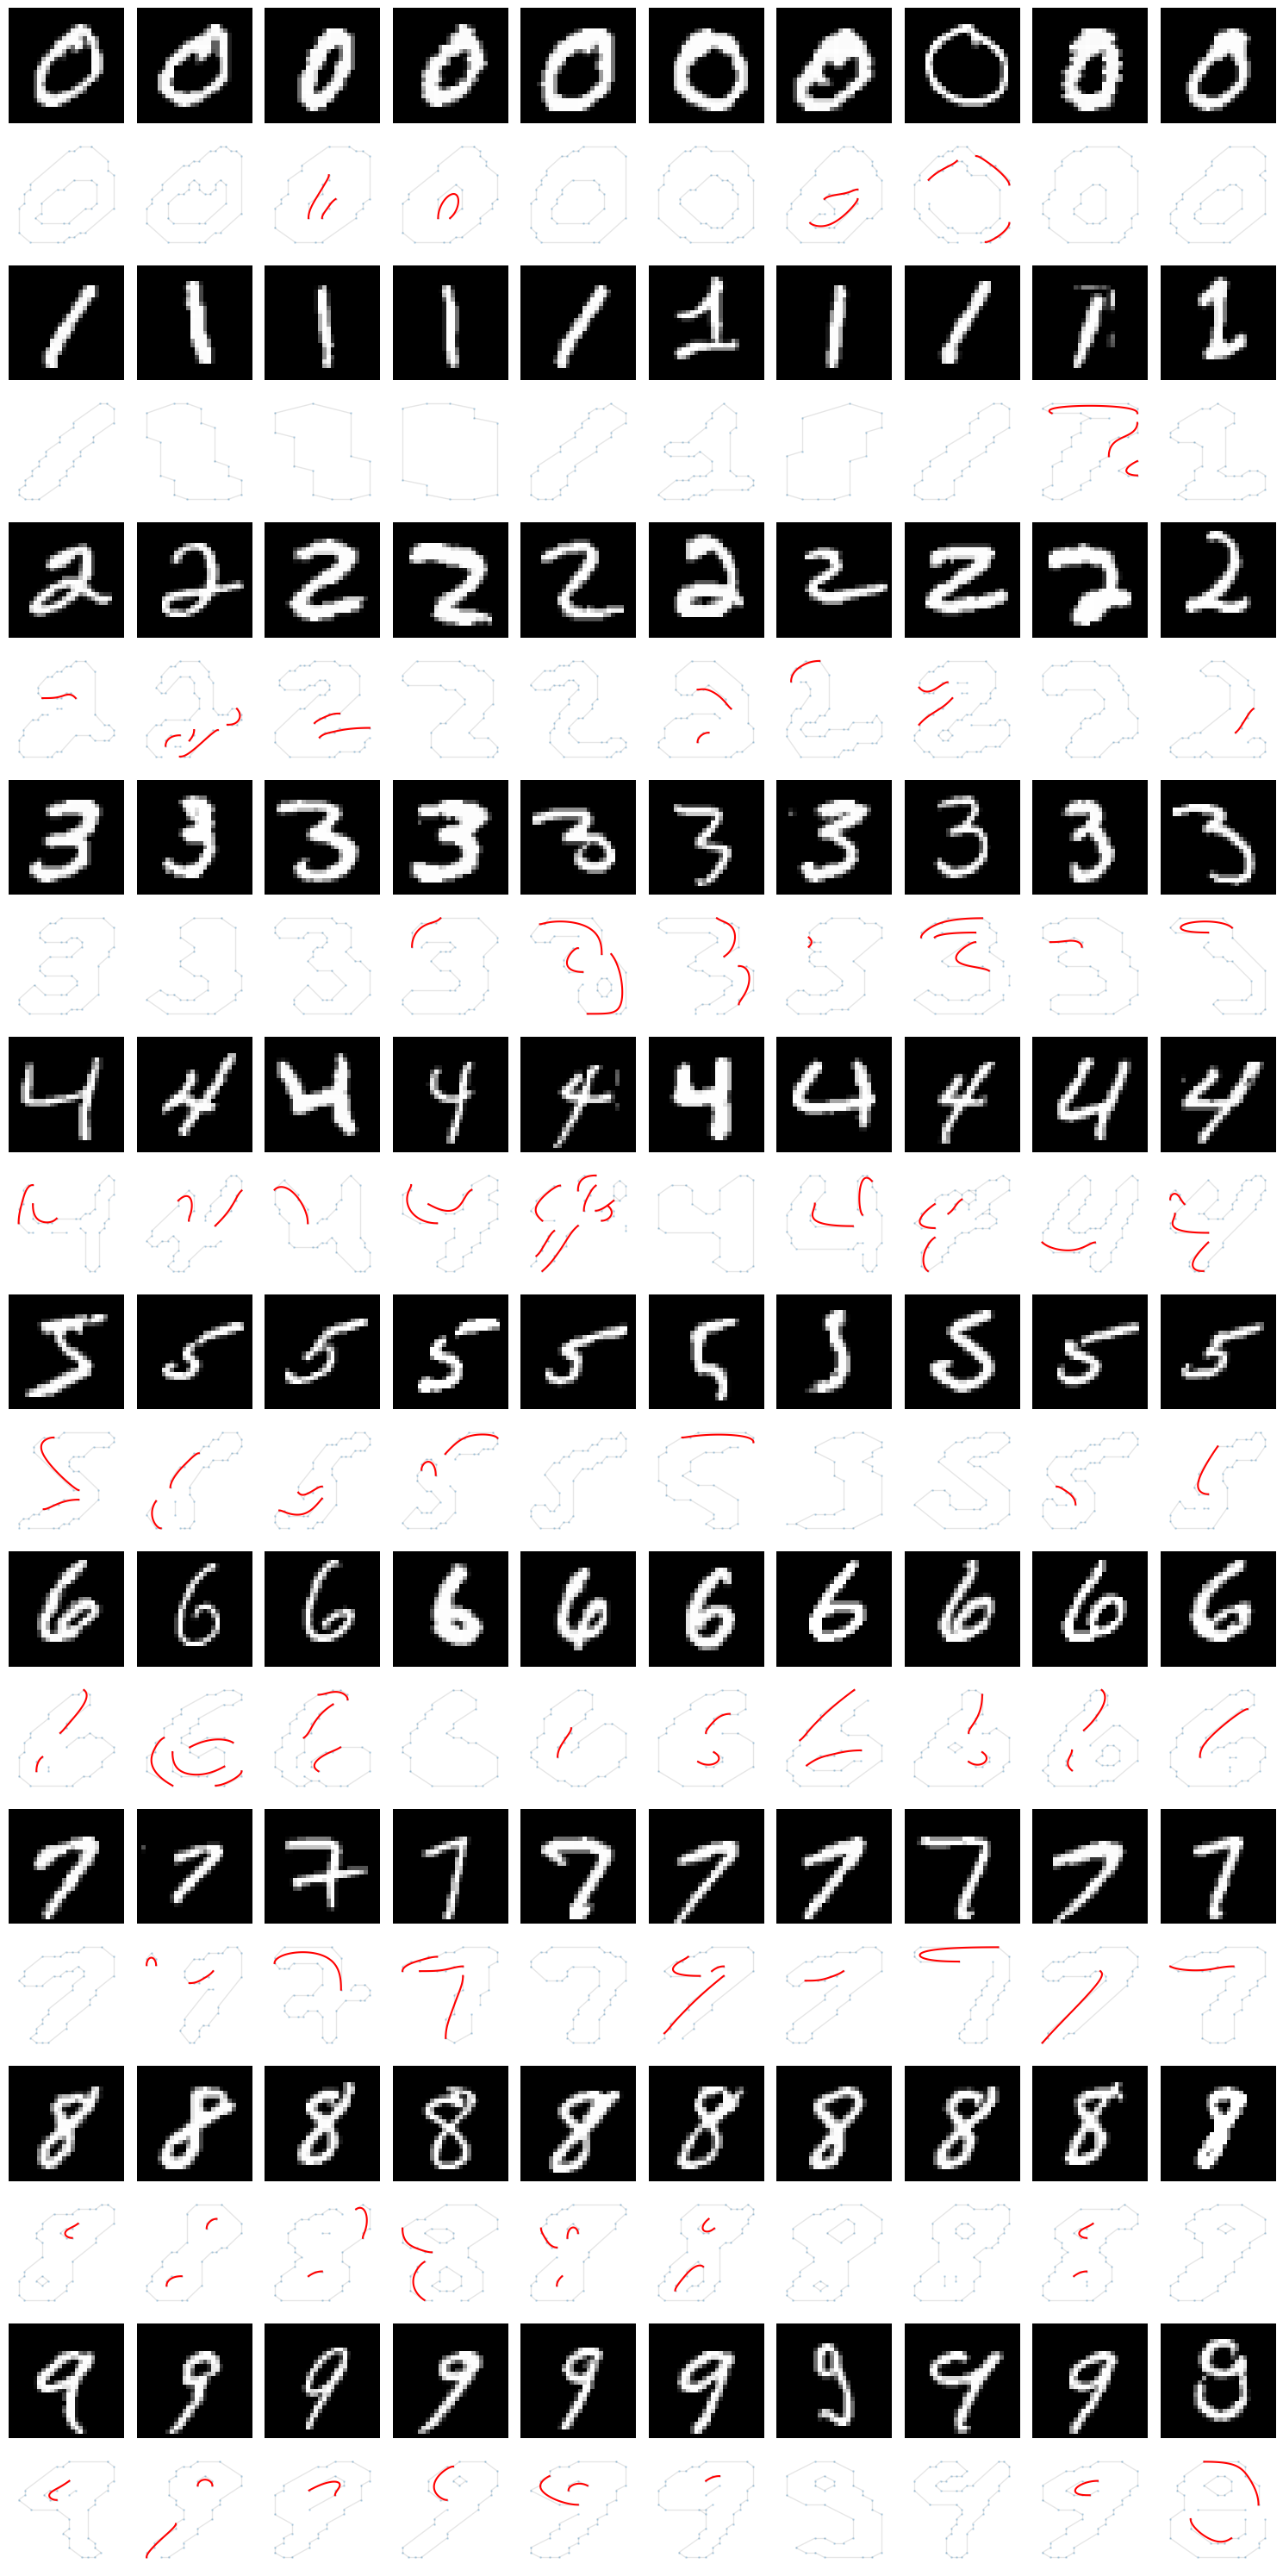

In [17]:
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')

        # Preprocess and extract graph

        G = mnist_to_graph(image)
        G = merge_similar_edges(G, angle_threshold=10)

        plot_graph_with_beziers_multigraph(G, axes[2 * i + 1, j])

        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()

### However circles fitting is still reliable 

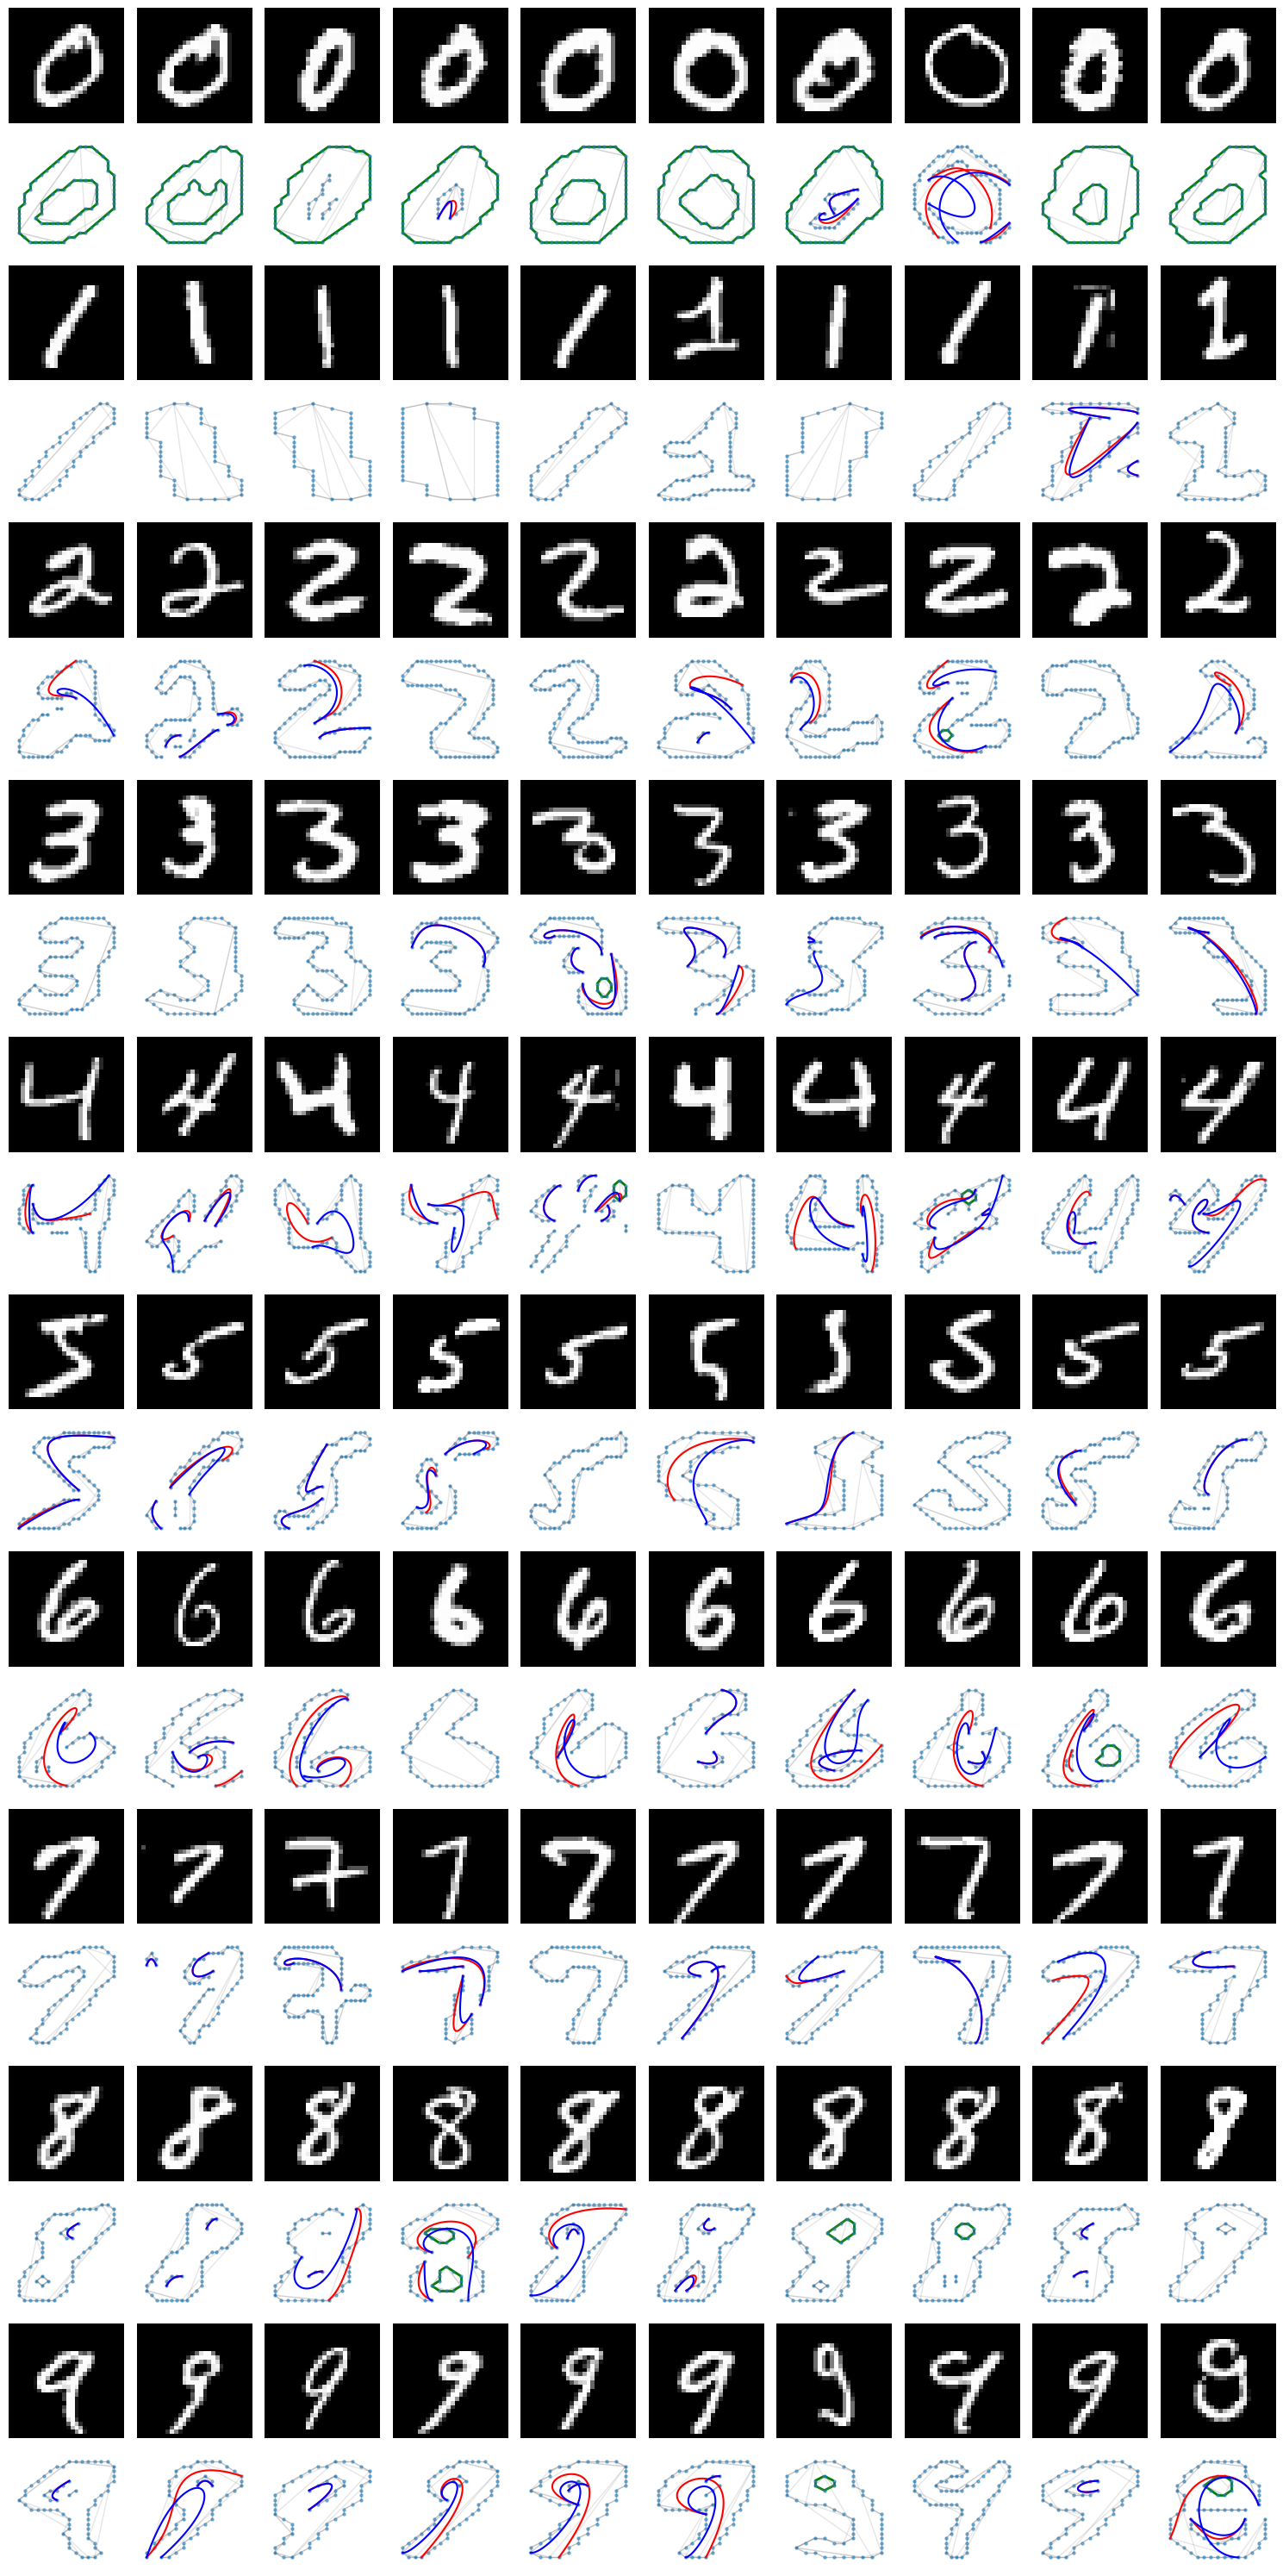

In [21]:
# Create a 10x10 grid of subplots for visualization
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

# Iterate over digits 0-9
for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        # Plot the images (first row)
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')

        # Preprocess the image and extract the graph
        G = merge_similar_edges(mnist_to_graph(image), angle_threshold=0)

        # Detect almost circular cycles in the graph
        almost_circles = detect_almost_circles(G, tolerance=0.3, min_length=4)

        # Plot the "almost circles" (second row)
        plot_almost_circles(G, almost_circles, axes[2 * i + 1, j])

        G1 = merge_similar_edges(mnist_to_graph(image), angle_threshold=50)
        
        # Optionally, plot Bézier curves on a separate row
        plot_graph_with_beziers_multigraph(G1, axes[2 * i + 1, j], "red")  # Uncomment this if needed

        G2 = merge_similar_edges(mnist_to_graph(image), angle_threshold=70)
        
        # Optionally, plot Bézier curves on a separate row
        plot_graph_with_beziers_multigraph(G2, axes[2 * i + 1, j], "blue")  # Uncomment this if needed

# Adjust layout and show
plt.tight_layout()
plt.show()